In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import h5py
import matplotlib.pyplot as plt
from os.path import join, exists
import os
import matplotlib as mpl
mpl.style.use('style.mcstyle')

# os.chdir('/home/x-mho1/git/ltu-cmass-run')

from astropy.cosmology import Planck18 as cosmo

In [3]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'
wdir = '/work/hdd/bdne/maho3/cmass-ili'

In [4]:
# Baseline
nbody = 'quijotelike'
sim = 'fastpm_4k_niall2'
tracer = 'galaxy'
postfix = 'kmin-0.0_kmax-0.4'
summlist = ['zPk0' , 'zPk2', 'zPk4', 'zBk0']
summaries = '+'.join(summlist)
modeldir = join(wdir, nbody, sim, 'models', tracer, summaries, postfix)
print(modeldir)

nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1]

/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4


/u/maho3/anaconda3/envs/cmass/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Study name: zPk0+zPk2+zPk4+zBk0
Number of trials: 149


/tmp/ipykernel_121708/3687992437.py:14: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study)
/tmp/ipykernel_121708/3687992437.py:15: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_param_importances(study)
/tmp/ipykernel_121708/3687992437.py:16: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_slice(study)


done


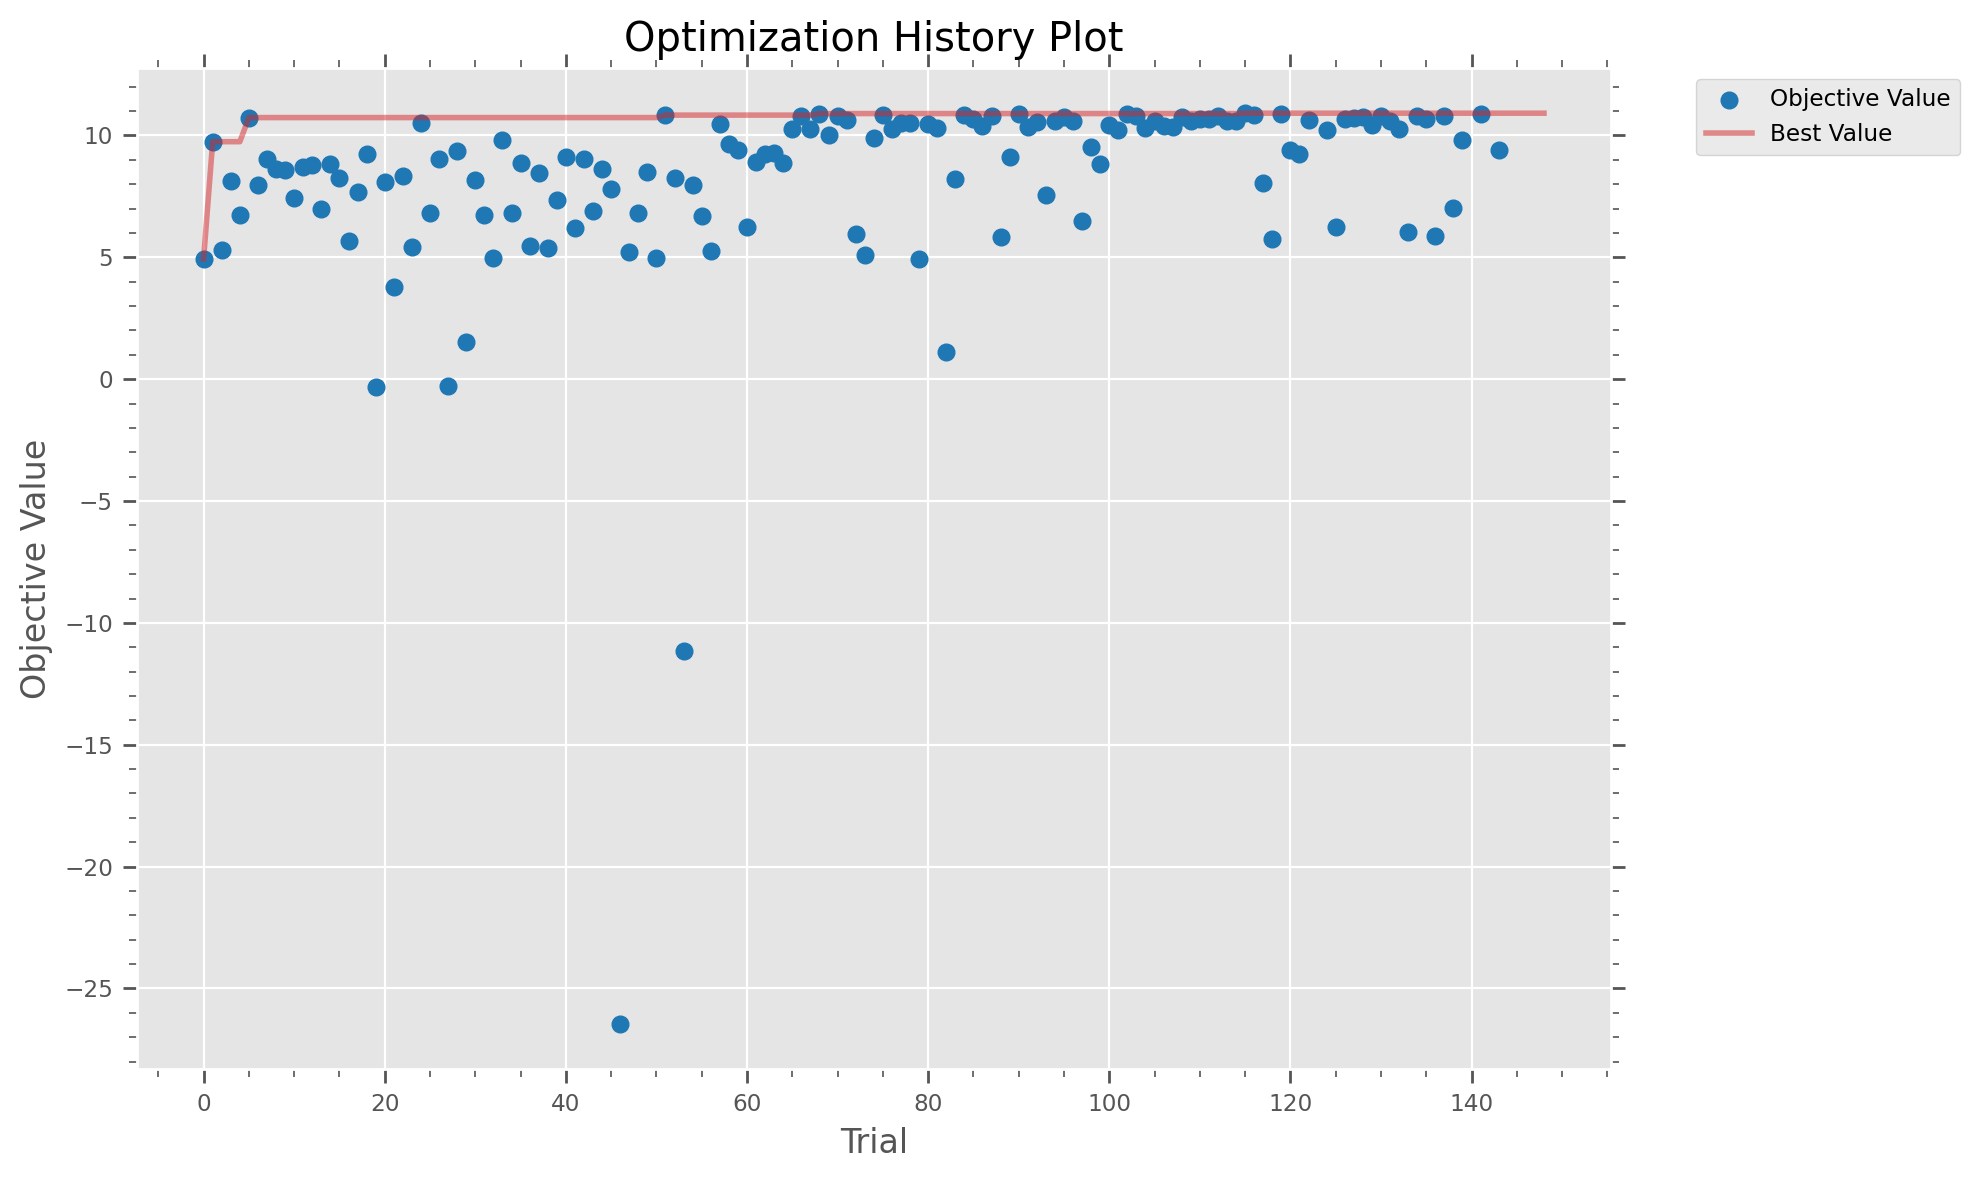

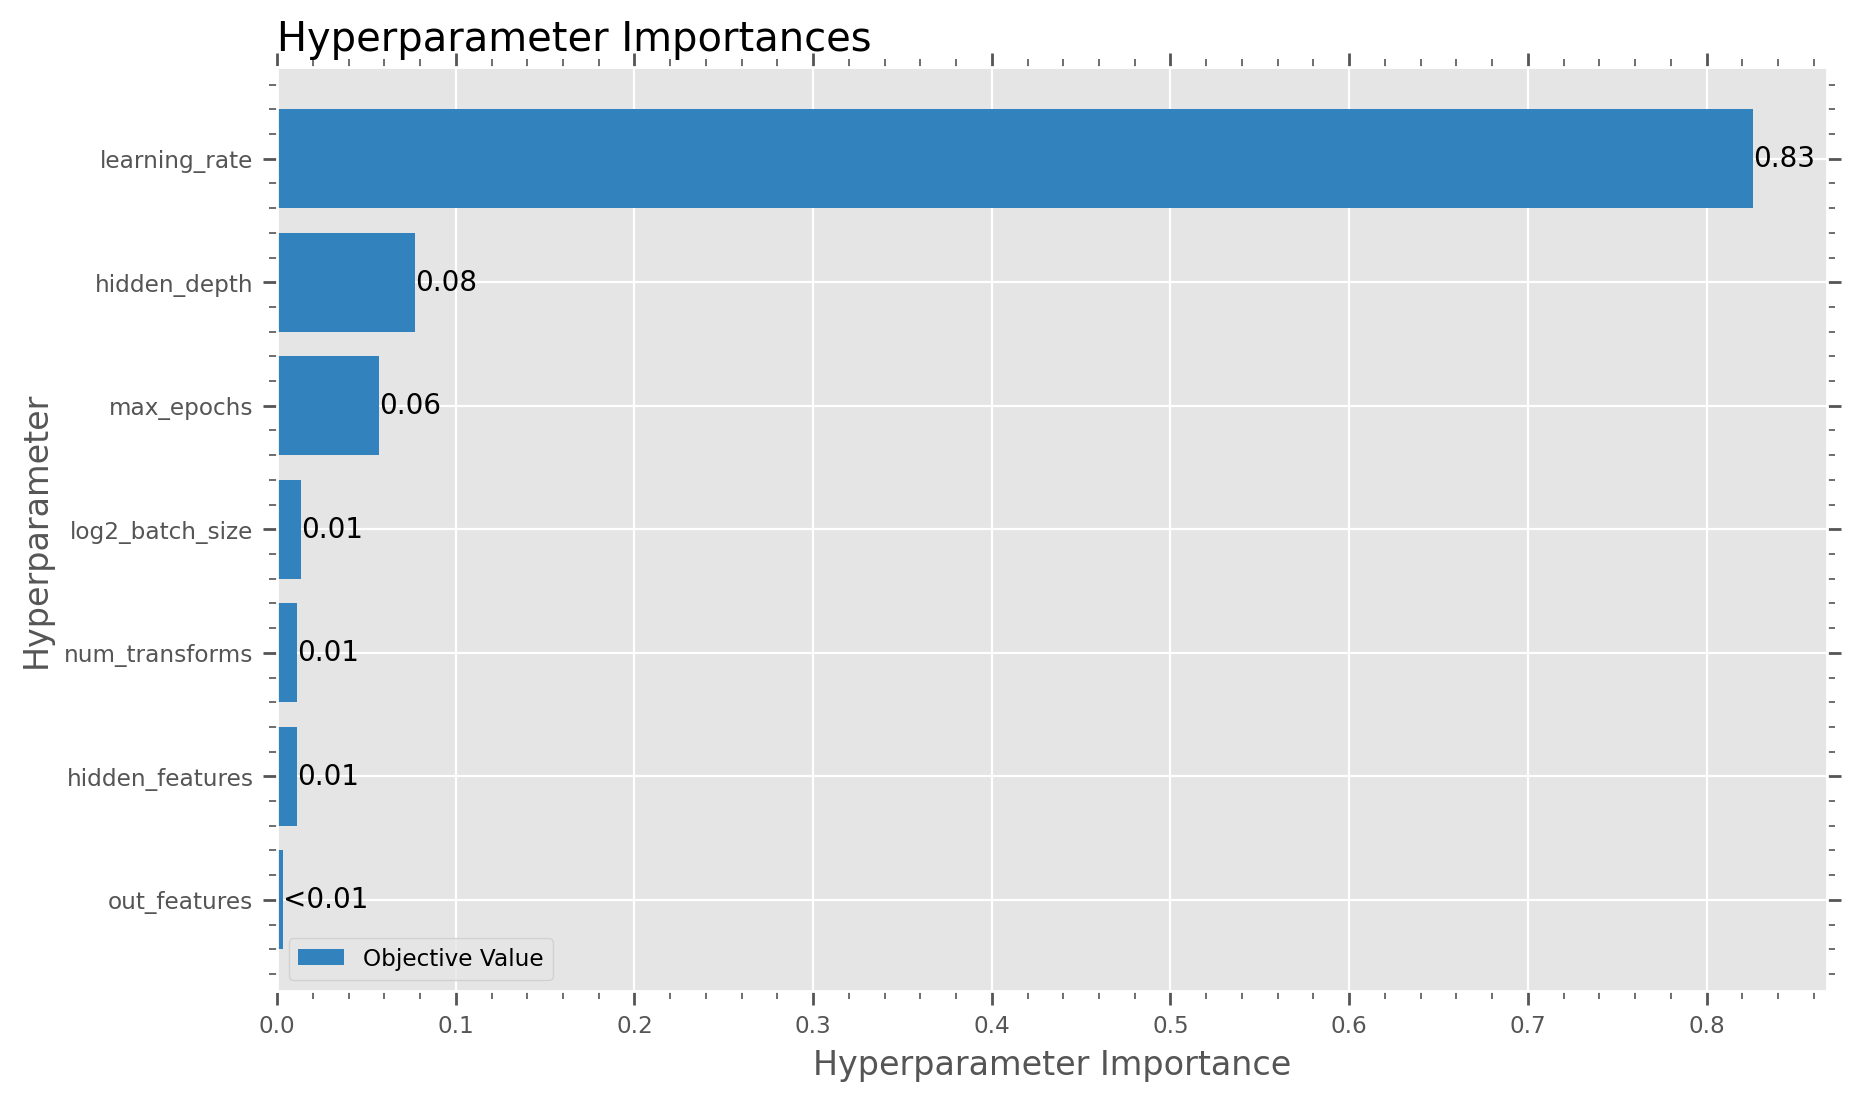

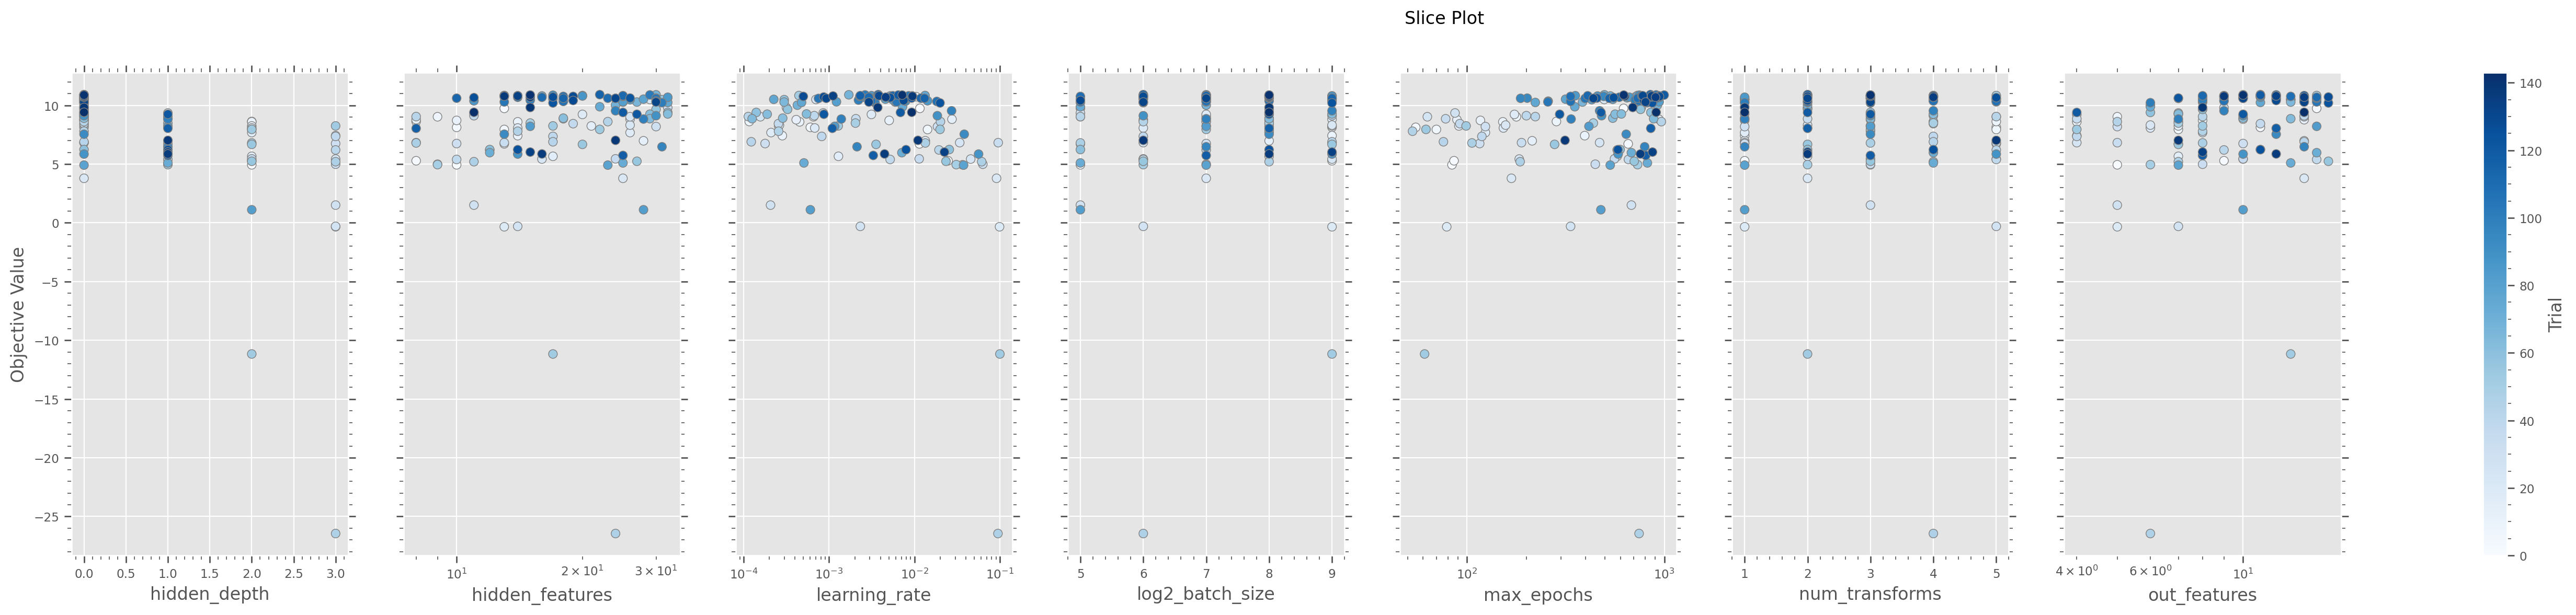

In [5]:
import optuna
import optuna.visualization.matplotlib as vis

filepath = join(modeldir, 'optuna_study.db')

# Load the 'summaries' study from the database
storage = f"sqlite:///{filepath}"
study = optuna.load_study(study_name=summaries, storage=storage)

# Print the study details
print(f"Study name: {study.study_name}")
print(f"Number of trials: {len(study.trials)}")

vis.plot_optimization_history(study)
vis.plot_param_importances(study)
vis.plot_slice(study)

print('done');

In [6]:
# vis.plot_contour(study, ['hidden_depth', 'out_features'])

In [7]:
parentdir = join(wdir, nbody, sim, 'models', tracer)

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])

stdev = {}
studies = []
for s in os.listdir(parentdir):
    print(s)
    modeldir = join(parentdir, s, postfix)
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        print('Missing samples. Skipping...')
        continue
    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))

    # Find indices where theta[:, :5] is close to thetafid
    mask = np.all(np.isclose(
        theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    print(f'Found {np.sum(mask)} samples close to fiducial')

    # Keep only those samples
    samples = samples[:, mask]

    stdev[s] = np.std(samples, axis=0)


    filepath = join(modeldir, 'optuna_study.db')

    # Load the 'summaries' study from the database
    storage = f"sqlite:///{filepath}"
    study = optuna.load_study(study_name=s, storage=storage)
    studies.append(study)

zPk0+zPk2+zPk4+zBk0
Found 149 samples close to fiducial
nbar+zPk0
Found 149 samples close to fiducial
zPk0+zPk2+zPk4+zEqBk0
Found 149 samples close to fiducial
nbar+zPk0+zPk2+zPk4+zBk0
Found 149 samples close to fiducial
zPk0+zPk2+zPk4
Found 149 samples close to fiducial
zPk0
Found 149 samples close to fiducial
nbar+zPk0+zPk2+zPk4
Found 149 samples close to fiducial


In [8]:
def simple(label):
    if isinstance(label, list):
        return [simple(l) for l in label]
    label = label.replace('nbar', r'$\bar{n}$')
    label = label.replace('zPk0+zPk2+zPk4', r'$zP_{0,2,4}$')
    label = label.replace('zPk0', r'$zP_{0}$')
    label = label.replace('zBk0', r'$zB_{0}$')
    label = label.replace('zQk0', r'$zQ_{0}$')
    label = label.replace('+', ', ')

    return label

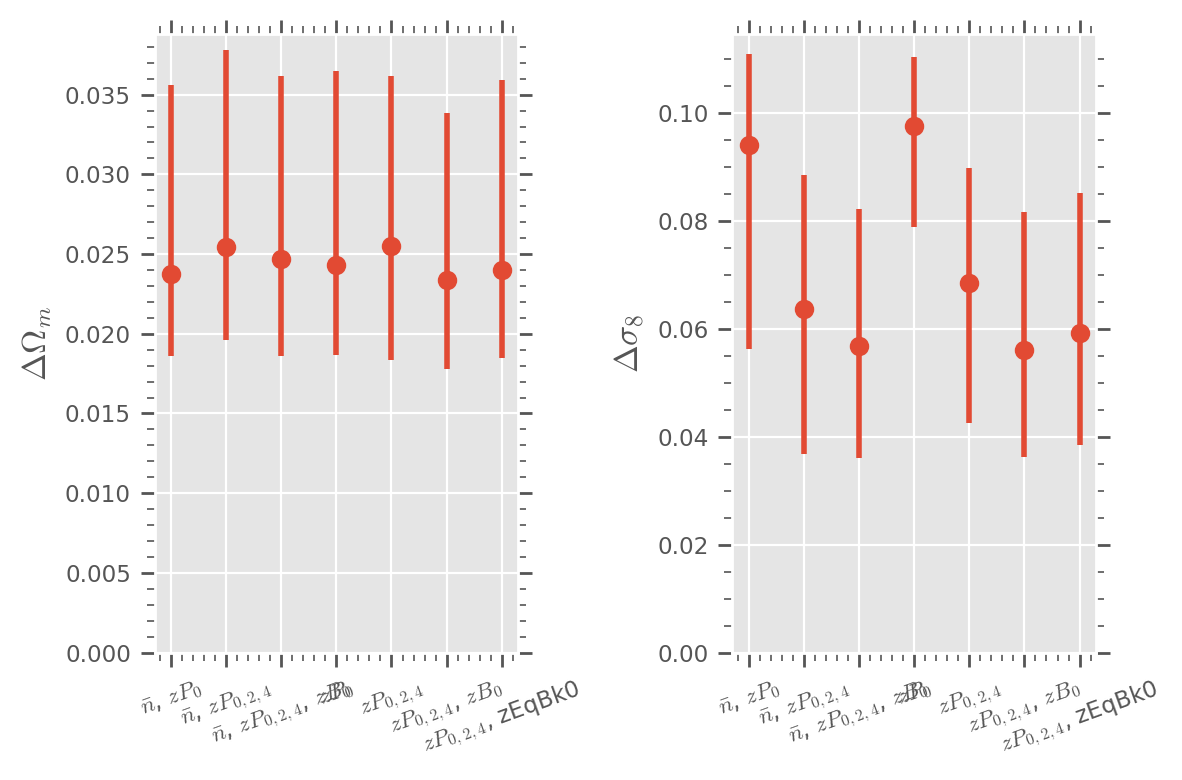

In [9]:
labels = sorted(list(stdev.keys()))

f, axs = plt.subplots(1,2, figsize=(6,4), sharex=True)
axs = axs.flatten()

names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

for j, i in enumerate([0, 4]):
    ax = axs[j]
    stdevs = [stdev[label][:, i] for label in labels]
    percentiles = np.percentile(stdevs, [50, 16, 84], axis=1)
    ax.errorbar(
        simple(labels), percentiles[0],
        yerr=[percentiles[0]-percentiles[1], percentiles[2]-percentiles[0]],
        fmt='o')
    ax.set_ylim(0)
    ax.set_ylabel(f'$\Delta {names[i]}$')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(simple(labels), rotation=20)

# axs[5].axis('off')
# axs[0].set_title('w/ BFast Bispectrum')
plt.tight_layout()

In [10]:
nbody = 'quijotelike'
sim = 'fastpm_4k_niall2'
tracer = 'galaxy'
z = 'z'

modeldirs = [
    f'{wdir}/{nbody}/{sim}/models/{tracer}/nbar+{z}Pk0/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/{sim}/models/{tracer}/nbar+{z}Pk0+{z}Pk2+{z}Pk4/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/{sim}/models/{tracer}/nbar+{z}Pk0+{z}Pk2+{z}Pk4+{z}Bk0/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/{sim}/models/{tracer}/{z}Pk0/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/{sim}/models/{tracer}/{z}Pk0+{z}Pk2+{z}Pk4/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/{sim}/models/{tracer}/{z}Pk0+{z}Pk2+{z}Pk4+{z}Bk0/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/fastpm_4k_hodz/models/{tracer}/{z}Pk0/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/fastpm_4k_hodz/models/{tracer}/{z}Pk0+{z}Pk2+{z}Pk4/kmin-0.0_kmax-0.4',
    f'{wdir}/{nbody}/fastpm_4k_hodz/models/{tracer}/{z}Pk0+{z}Pk2+{z}Pk4+{z}Bk0/kmin-0.0_kmax-0.4',
]

names = [
    m.split('/')[-2] for m in modeldirs
]

x_len = []
for m in modeldirs:
    x_ = np.load(join(m, 'x_test.npy'))
    x_len.append(x_.shape[-1])

In [11]:
cmap = mpl.colormaps['tab20'].colors

(9.0, 11.5)

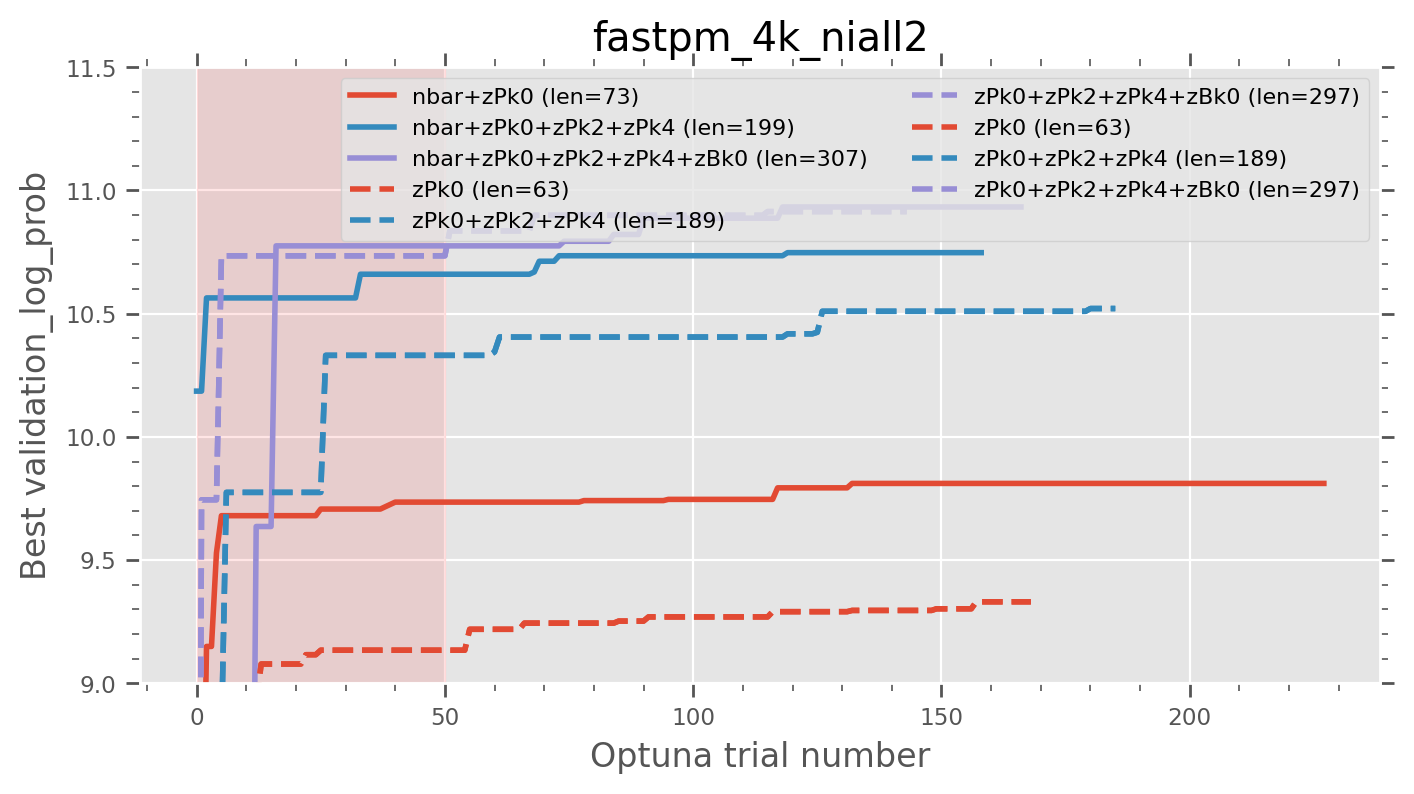

In [12]:

def plot_history(modeldir, ax, **kwargs):
    storage = f"sqlite:///{modeldir}/optuna_study.db"
    study = optuna.load_study(study_name=modeldir.split('/')[-2], storage=storage)
    trials = study.trials
    trial_numbers = [t.number for t in trials if t.value is not None]
    values = [t.value for t in trials if t.value is not None]
    
    best_values = np.maximum.accumulate(values)
    
    ax.plot(trial_numbers, best_values, **kwargs)

f, ax = plt.subplots(figsize=(8,4))
for i, m in enumerate(modeldirs):
    plot_history(m, ax, label=f"{names[i]} (len={x_len[i]})", c=f'C{i%3}',
                 ls='-' if i//3==0 else '--')

ax.fill_between([0,50],[0]*2,[120]*2, color='r', alpha=0.1)
ax.legend(fontsize=8, ncol=2) # loc='middle right')
ax.set(xlabel='Optuna trial number', ylabel='Best validation_log_prob')
ax.set_title(sim)
ax.set_ylim(9, 11.5)

Text(0.5, 0.98, 'fastpm_4k_niall2')

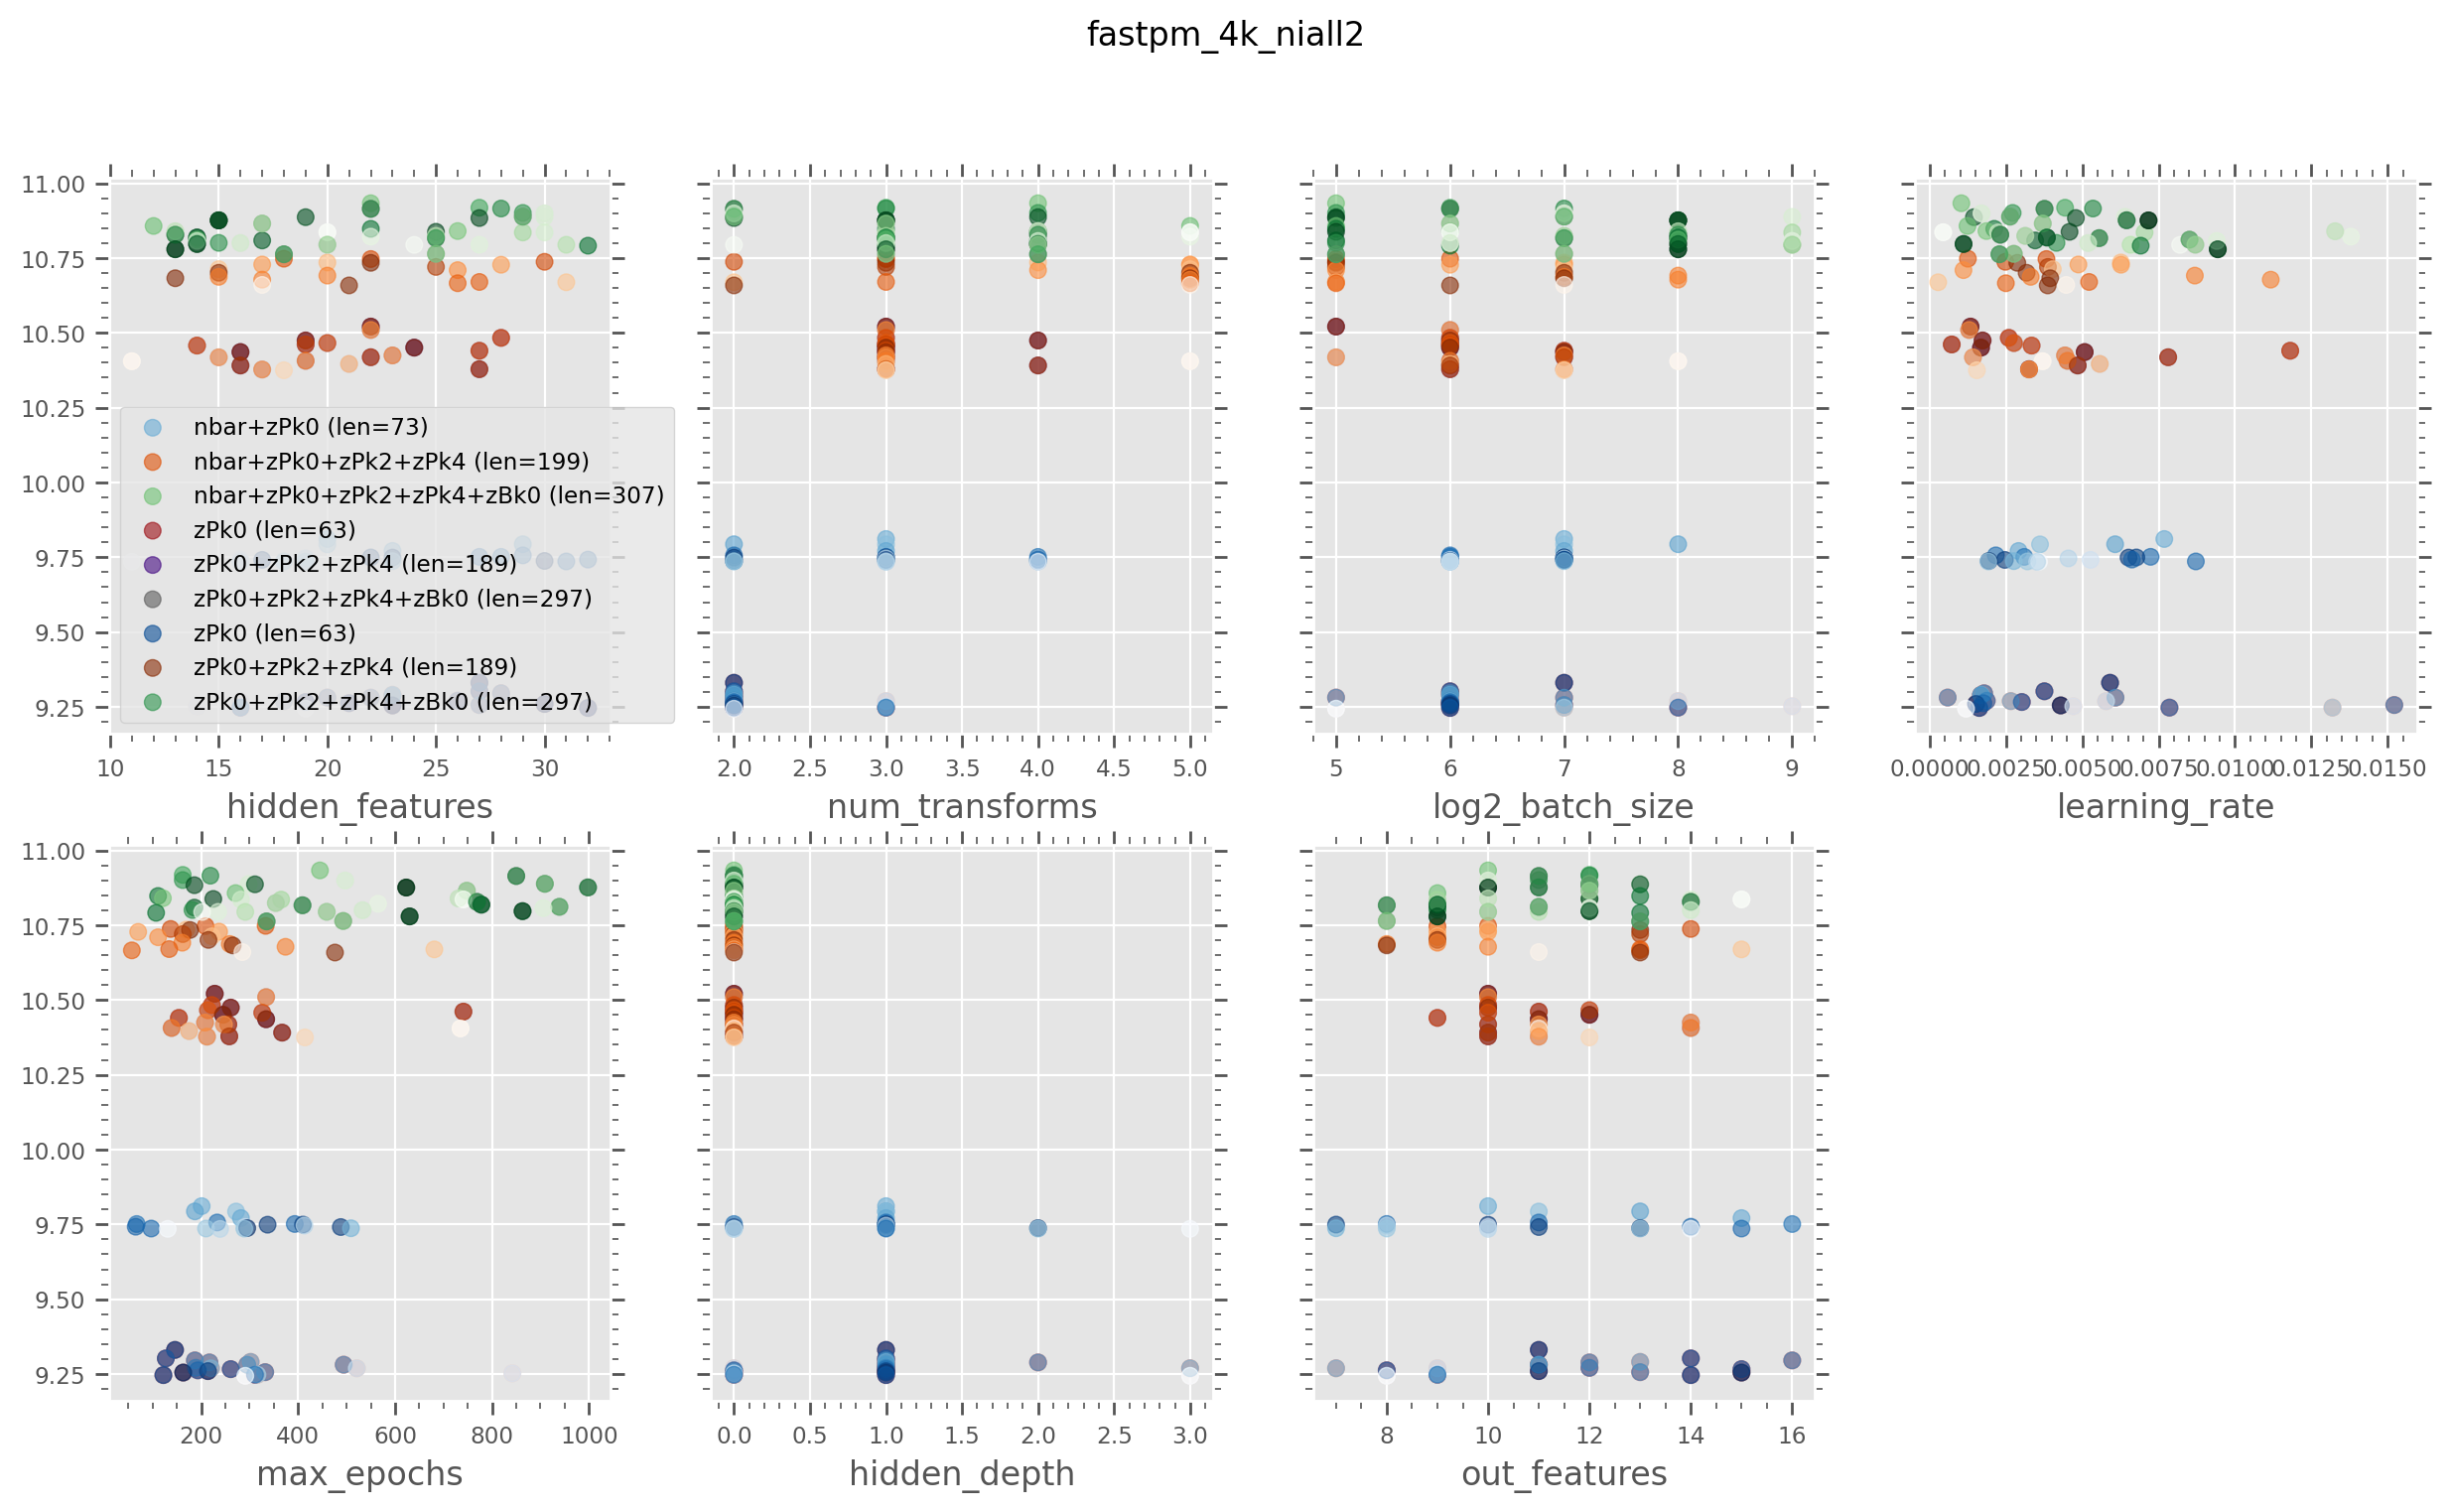

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import optuna

def plot_param_dependence(modeldir, axs, **kwargs):
    Ntrials = 20
    storage = f"sqlite:///{modeldir}/optuna_study.db"
    study = optuna.load_study(study_name=modeldir.split('/')[-2], storage=storage)
    trials = [t for t in study.trials if t.value is not None]
    best_trials = sorted(trials, key=lambda t: t.value, reverse=True)[:Ntrials]

    param_names = list(best_trials[0].params.keys())
    nplots = len(param_names)
    
    y = [t.value for t in best_trials]
    # Extract trial numbers to map to color intensity
    trial_nums = [t.number for t in best_trials]
    
    # Pop cmap and alpha out of kwargs with defaults so they don't clash with scatter
    cmap = kwargs.pop('cmap', 'Greys')
    alpha = kwargs.pop('alpha', 0.6) # Reduced alpha

    for ax, pname in zip(axs[:nplots], param_names[:nplots]):
        x = [t.params.get(pname, np.nan) for t in best_trials]
        
        # Pass trial_nums to 'c' to map colors, and apply the cmap and alpha
        ax.scatter(x, y, c=trial_nums, cmap=cmap, alpha=alpha, **kwargs)
        ax.set_xlabel(pname)

    for ax in axs[nplots:]:
        ax.set_visible(False)

f, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 8), 
                      gridspec_kw={'hspace': 0.2})
axs = axs.flatten()

# Provide a list of sequential colormaps that get darker as values increase
# Standard matplotlib sequential maps: Blues, Oranges, Greens, Reds, Purples, etc.
cmaps = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 'Greys']

for i, m in enumerate(modeldirs):
    # Cycle through the colormaps based on the index
    model_cmap = cmaps[i % len(cmaps)]
    plot_param_dependence(
        m, 
        axs, 
        label=f"{names[i]} (len={x_len[i]})", 
        cmap=model_cmap
    )

ax = axs[0]
ax.legend()
f.suptitle(sim)

Text(0.5, 0.98, 'fastpm_4k_niall2')

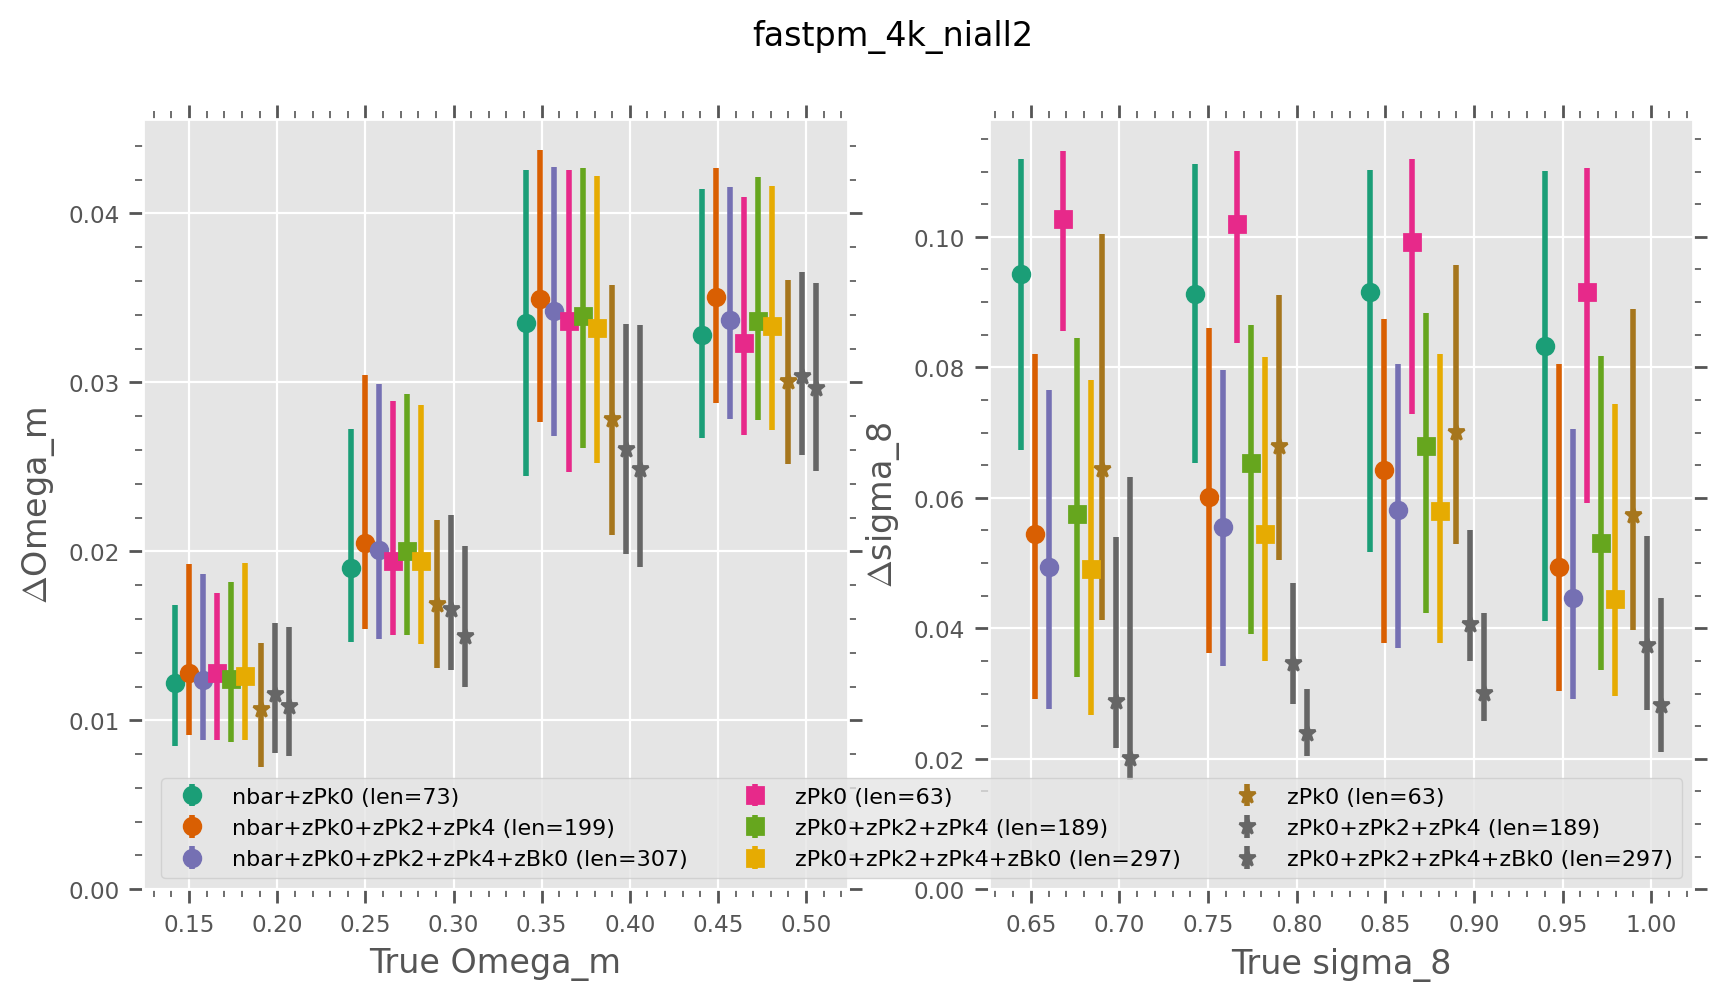

In [14]:
def plot_scatter(modeldir, axs, offset=0, **kwargs):
    samples = np.load(join(modeldir, 'posterior_samples.npy'))
    theta = np.load(join(modeldir, 'theta_test.npy'))

    stdev = samples.std(axis=0)

    Nbins = 4
    for i, (j, label) in enumerate(zip([0,4], ['Omega_m', 'sigma_8'])):
        ax = axs[i]

        minmax = theta[:, j].min(), theta[:, j].max()
        off = offset*np.diff(minmax)

        bin_edges = np.linspace(*minmax, num=Nbins+1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        y_ = []
        for k in range(Nbins):
            mask = (theta[:, j] >= bin_edges[k]) & (theta[:, j] < bin_edges[k+1])
            y_.append(np.percentile(stdev[mask,j], [50, 16, 84]))
        y_ = np.array(y_)

        ax.errorbar(bin_centers+off, y_[:, 0], 
                    yerr=[y_[:, 0] - y_[:, 1], y_[:, 2] - y_[:, 0]], 
                    **kwargs)
        ax.set_xlabel(f'True {label}')
        ax.set_ylabel(f'$\Delta${label}')
        
f, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, m in enumerate(modeldirs):
    offperc = (i-1)*0.02
    fmt = ['o', 's', '*'][i//3]
    plot_scatter(m, axs, offset=offperc, 
                 label=f"{names[i]} (len={x_len[i]})",
                 color=plt.cm.Dark2(i),
                 fmt=fmt)

axs[1].legend(fontsize=8, ncols=3, loc='lower right')
axs[0].set_ylim(0)
axs[1].set_ylim(0)
f.suptitle(sim)

In [29]:
modeldirs

['/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/nbar+zPk0/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/nbar+zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/zPk0/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy/zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_hodz/models/galaxy/zPk0/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_hodz/models/galaxy/zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
 '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_hodz/models/galaxy/zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4']

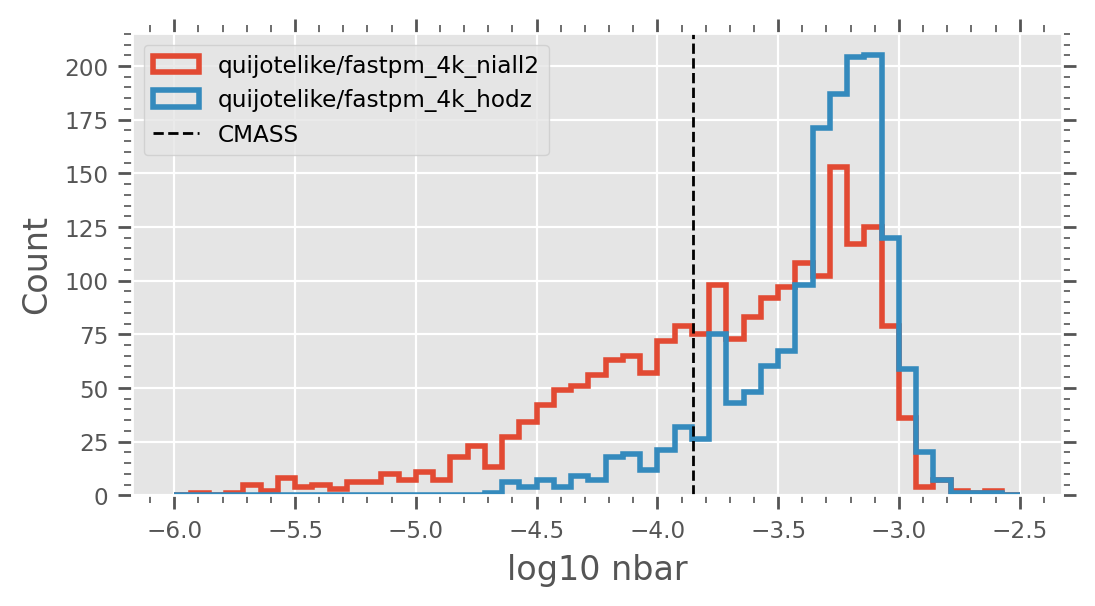

In [39]:
f, ax = plt.subplots(figsize=(6,3))

bins = np.linspace(-6.0, -2.5, 50)
for m in modeldirs[5:7]:
    filepath = join(m, 'nbar_test.npy')
    x_ = np.load(filepath)
    ax.hist(x_, bins=bins, histtype='step', lw=2, label='/'.join(m.split('/')[6:8]))
ax.axvline(np.log10(1.4e-4), color='k', linestyle='--', lw=1, label='CMASS')
ax.set(xlabel='log10 nbar', ylabel='Count')
ax.legend()

Text(0.5, 0.98, 'fastpm_4k_niall2')

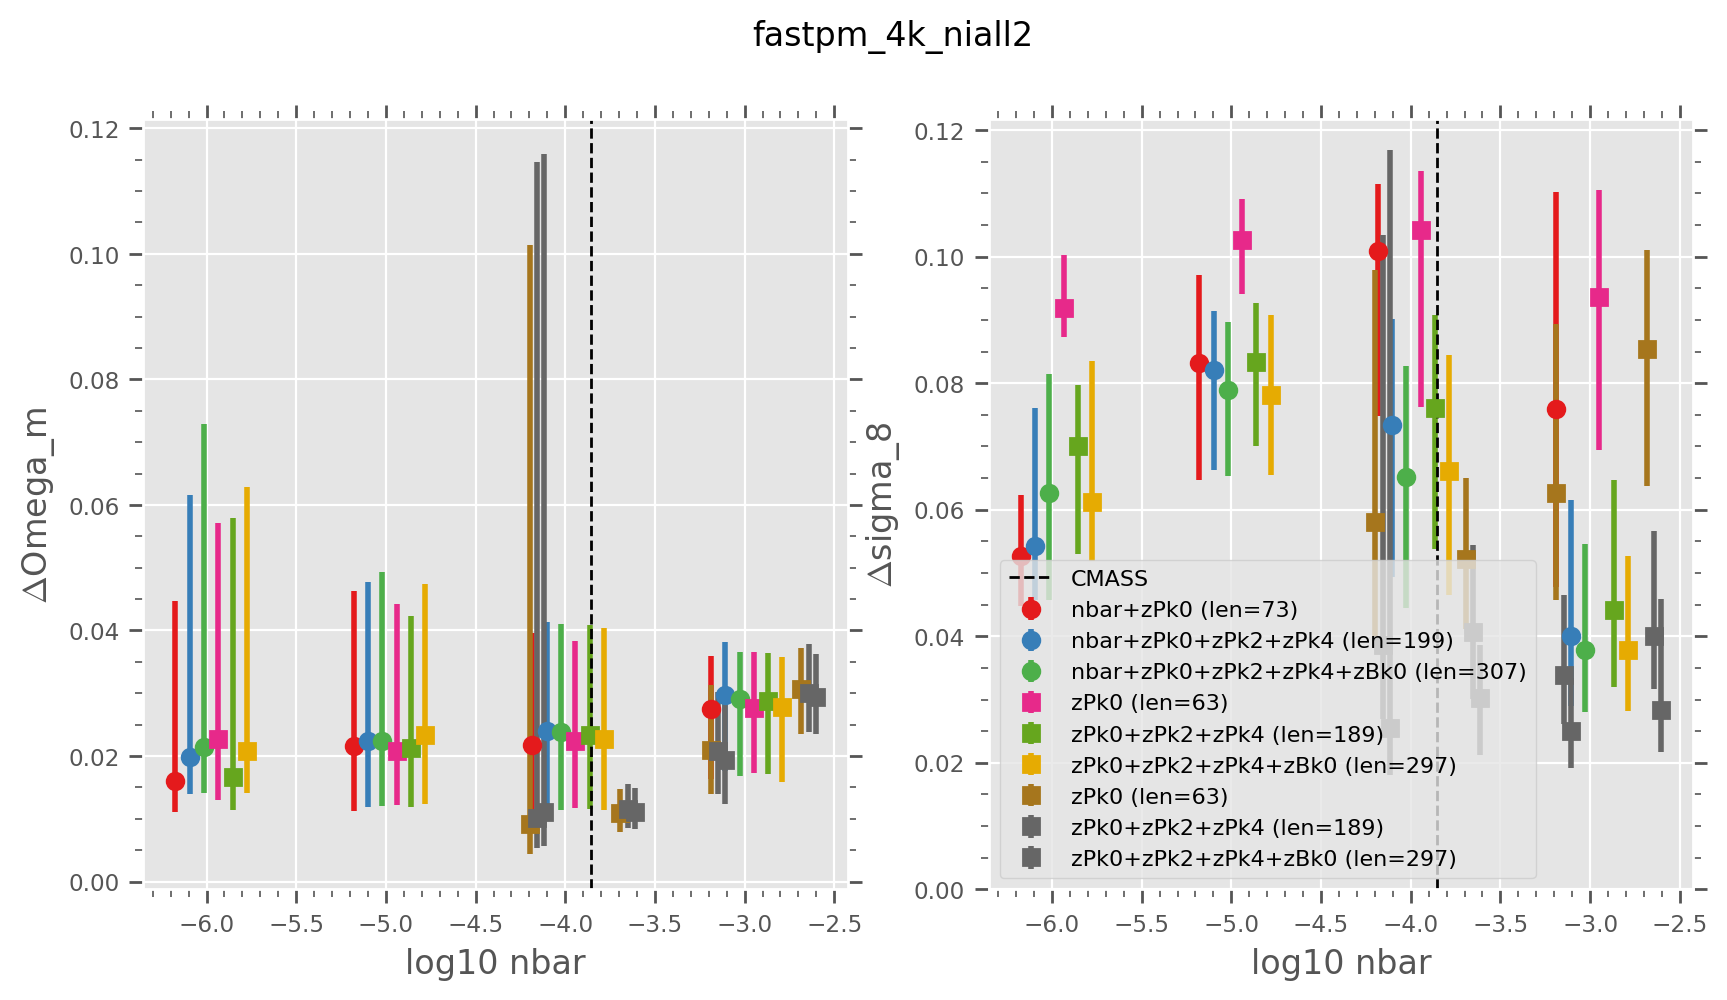

In [23]:
def plot_scatter(modeldir, ax, offset=0, **kwargs):
    samples = np.load(join(modeldir, 'posterior_samples.npy'))
    nbar = np.load(join(modeldir, 'nbar_test.npy'))

    stdev = samples.std(axis=0)

    Nbins = 4
    for i, (j, label) in enumerate(zip([0,4], ['Omega_m', 'sigma_8'])):
        ax = axs[i]

        minmax = nbar.min(), nbar.max()
        off = offset*np.diff(minmax)

        bin_edges = np.linspace(*minmax, num=Nbins+1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        y_ = []
        for k in range(Nbins):
            mask = (nbar >= bin_edges[k]) & (nbar < bin_edges[k+1])
            y_.append(np.percentile(stdev[mask,j], [50, 16, 84]))
        y_ = np.array(y_)

        ax.errorbar(bin_centers+off, y_[:, 0], 
                    yerr=[y_[:, 0] - y_[:, 1], y_[:, 2] - y_[:, 0]], 
                    **kwargs)
        ax.set_xlabel(f'log10 nbar')
        ax.set_ylabel(f'$\Delta${label}')
        
    ax.legend()
f, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, m in enumerate(modeldirs):
    offperc = (i-1)*0.02
    plot_scatter(m, axs, offset=offperc, 
                 label=f"{names[i]} (len={x_len[i]})",
                 color=plt.cm.Set1(i) if i//3==0 else plt.cm.Dark2(i),
                 fmt='o' if i//3==0 else 's')

for ax in axs:
    ax.axvline(np.log10(1.4e-4), color='k', linestyle='--', lw=1, label='CMASS')
ax.legend(fontsize=8)
ax.set_ylim(0)
f.suptitle(sim)

Found 48 samples close to fiducial.
Found 48 samples close to fiducial.
Found 48 samples close to fiducial.
Found 48 samples close to fiducial.
Found 48 samples close to fiducial.
Found 48 samples close to fiducial.
Found 9 samples close to fiducial.
Found 9 samples close to fiducial.
Found 9 samples close to fiducial.


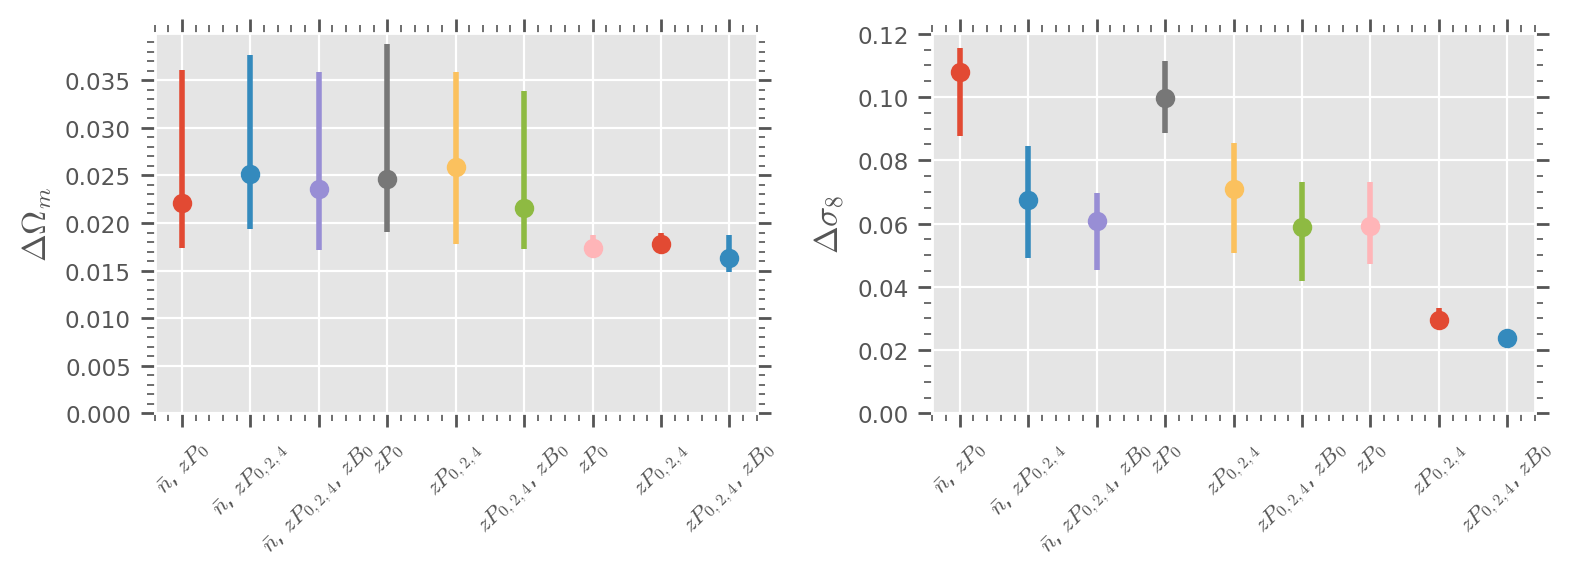

In [41]:
thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
param_names = [r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8']

def plot_model_stdev(modeldir, x_idx, axs, **kwargs):
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        return False

    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))
    nbar = np.load(join(modeldir, 'nbar_test.npy'))

    mask = np.all(np.isclose(theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4)) & (nbar < -3.4)
    
    if np.sum(mask) == 0:
        return False

    # Keep only samples close to fiducial
    filtered_samples = samples[:, mask]
    print(f'Found {np.sum(mask)} samples close to fiducial.')
    stdev = np.std(filtered_samples, axis=0)

    for j, i in enumerate([0, 4]):
        ax = axs[j]
        
        # Calculate percentiles across the surviving test points for this model
        param_stdevs = stdev[:, i]
        perc = np.percentile(param_stdevs, [50, 16, 84])
        
        ax.errorbar(
            x_idx, perc[0],
            yerr=[[perc[0] - perc[1]], [perc[2] - perc[0]]],
            fmt='o', **kwargs
        )
        ax.set_ylabel(f'$\Delta {param_names[i]}$')
        
    return True


f, axs = plt.subplots(1, 2, figsize=(8, 3), sharex=True)
axs = axs.flatten()

parentdir = f'{wdir}/{nbody}/{sim}/models/{tracer}'

labels = sorted(os.listdir(parentdir))
valid_labels = []
x_idx = 0

for m in modeldirs:
    label = f"{m.split('/')[-2]}"    
    # Plot the point at the current x_idx. If data exists, advance the index and save the label.
    if plot_model_stdev(m, x_idx, axs, label=label):
        valid_labels.append(label)
        x_idx += 1

# Apply the categorical x-axis formatting from Cell 1
for ax in axs:
    ax.set_xticks(range(len(valid_labels)))
    ax.set_xticklabels(simple(valid_labels), rotation=45)
    ax.set_ylim(0, None)
# ax.legend(loc='lower right')

# f.suptitle(sim)
plt.tight_layout()

nbar+zPk0 [0.3353  0.06801 0.6367  1.0071  0.7339 ] -3.2611631770797356
zPk0 [0.3353  0.06801 0.6367  1.0071  0.7339 ] 1.5326107064591064


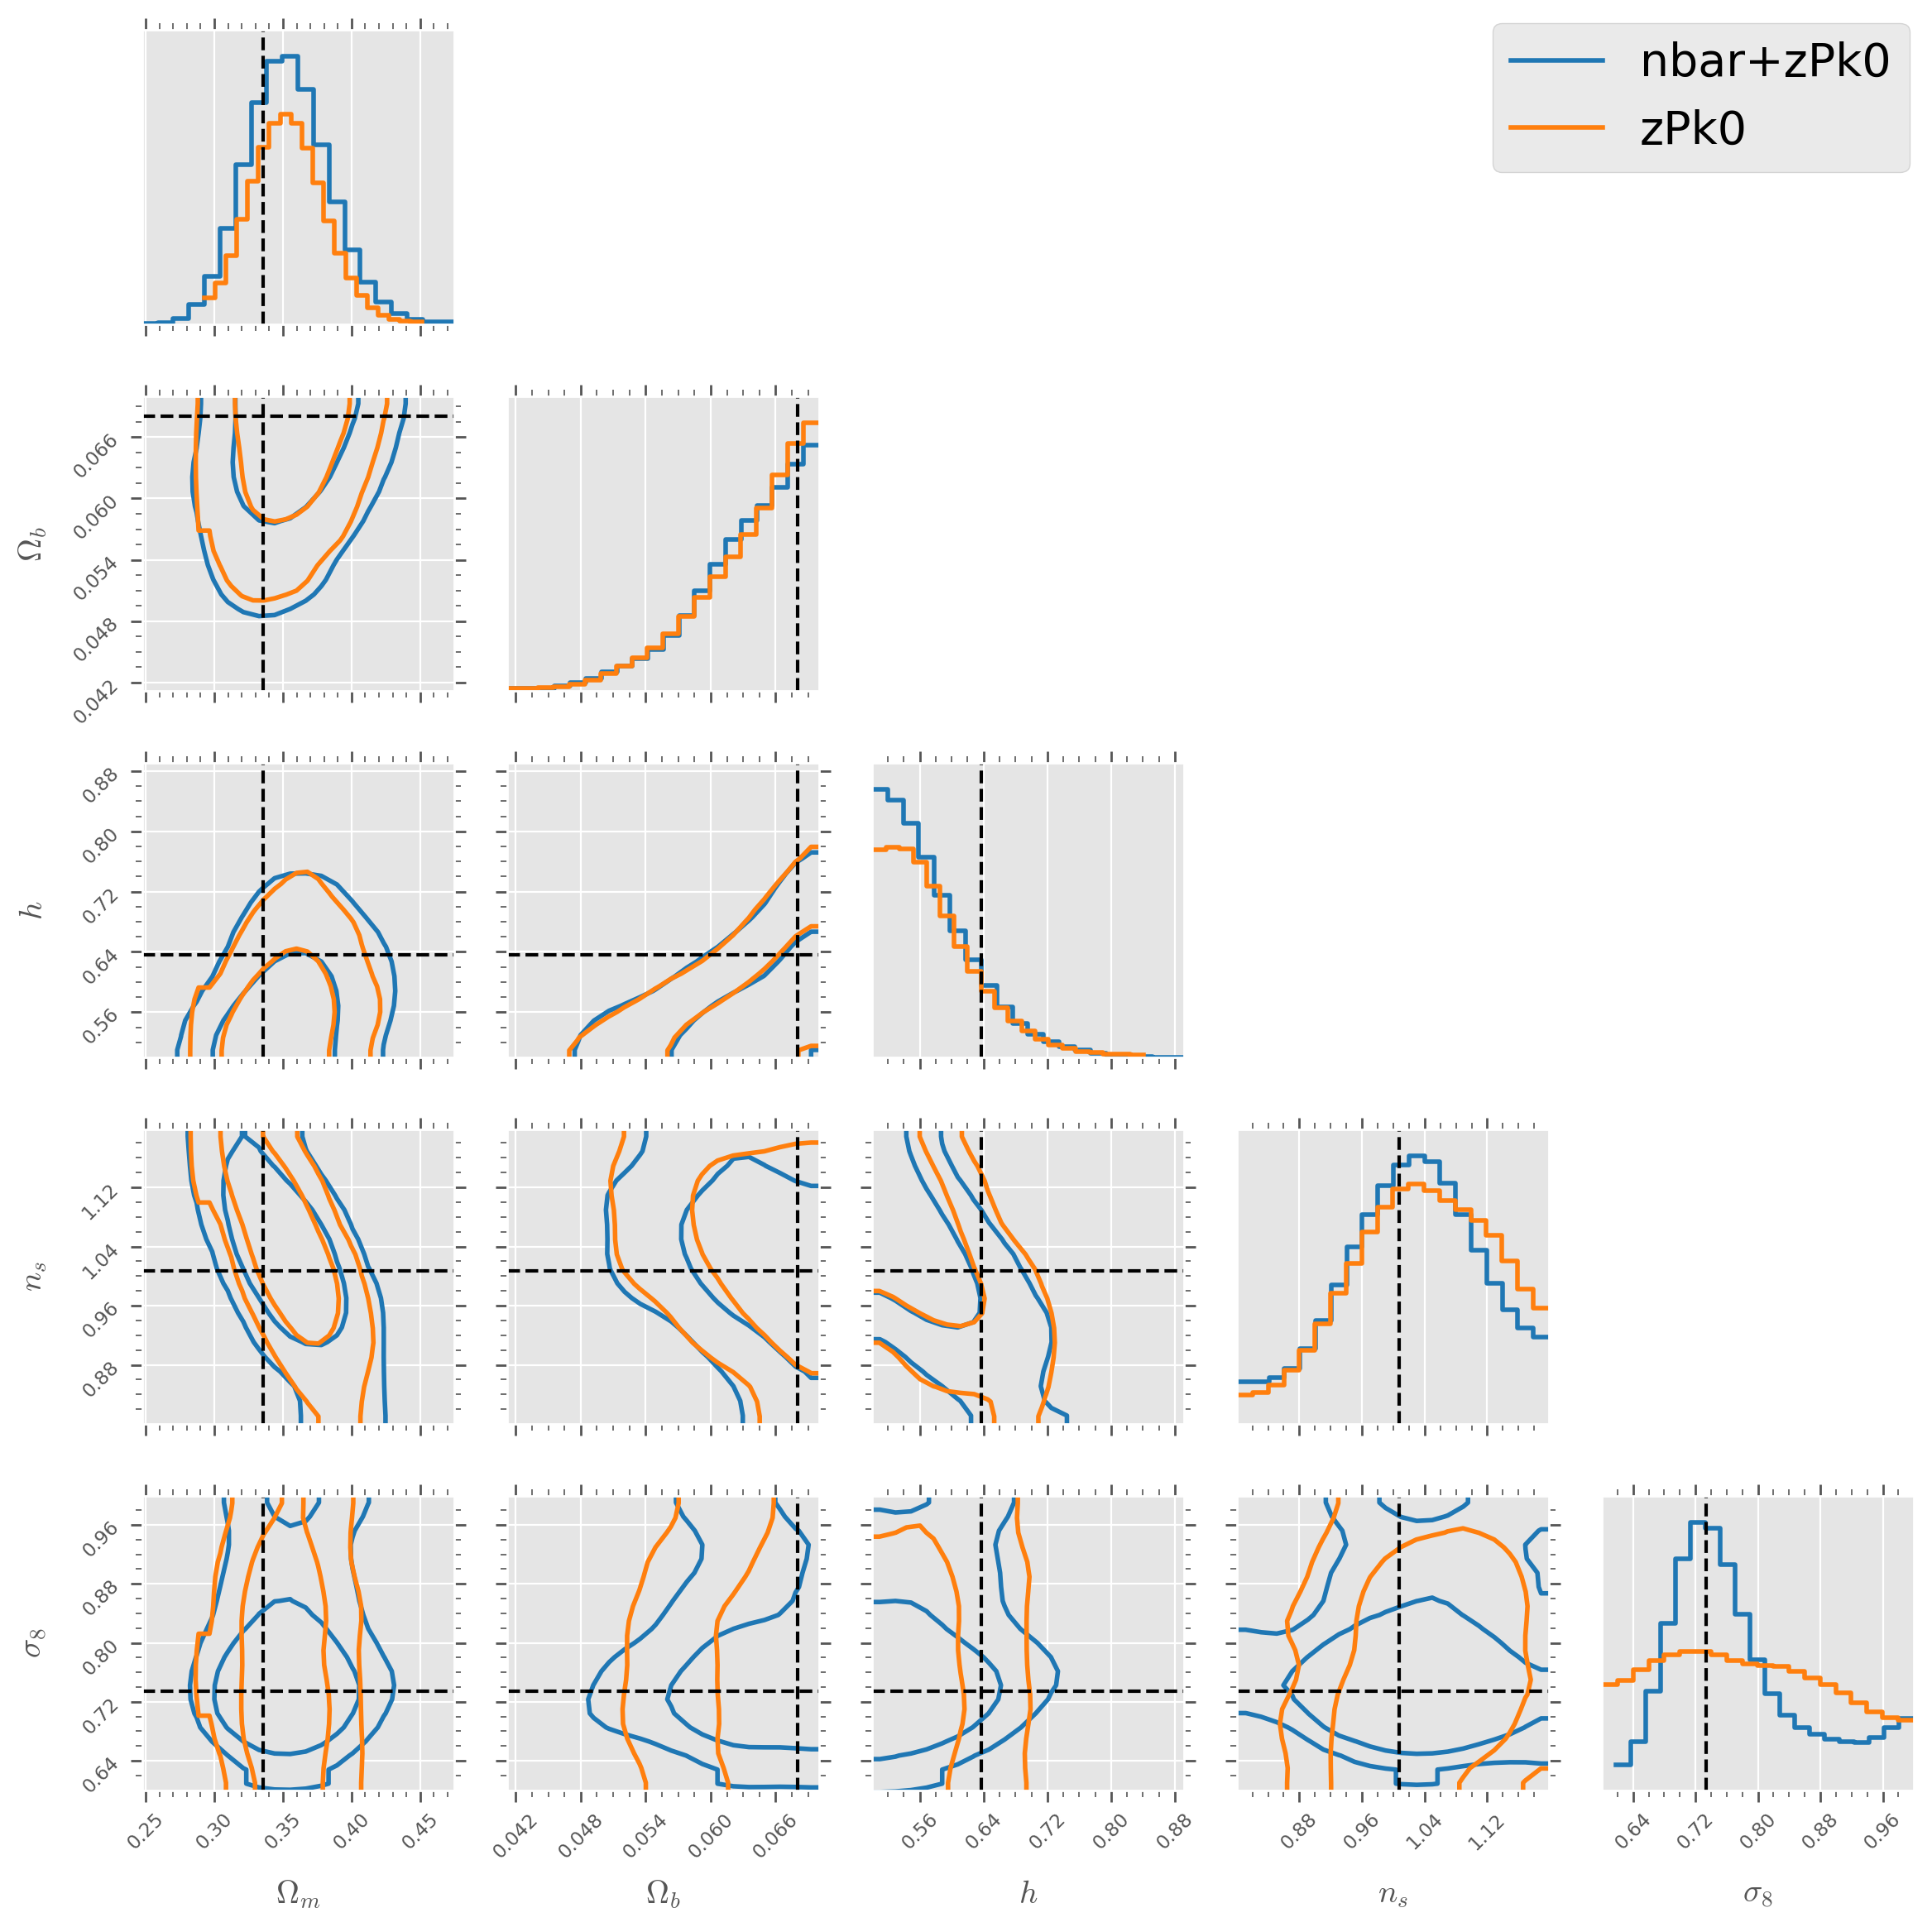

In [50]:
import corner

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
param_idxs = [0, 1, 2, 3, 4]

parentdir = f'{wdir}/{nbody}/{sim}/models/{tracer}'
labels = ['nbar+zPk0','zPk0']

fig = None
colors = plt.cm.tab10(np.linspace(0, 1, 10))

ci = 0
valid_labels = []
true_theta = None
best_idx = None

for s in labels:
    modeldir = join(parentdir, s, postfix)
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        continue

    samples = np.load(filepath)[:,:,:5]
    theta = np.load(join(modeldir, 'theta_test.npy'))[:,:5]
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1]

    # Only pick best_idx on the first valid label
    if best_idx is None:
        mask = nbar > np.log10(1.4e-4)
        dists = np.sqrt(np.sum((theta - thetafid) ** 2, axis=1))
        dists[~mask] = np.inf
        best_idx = np.argsort(dists)[9]
        if np.isinf(dists[best_idx]):
            best_idx = None
            continue
        true_theta = theta[best_idx]

    samps = samples[:, best_idx]
    print(s, true_theta, nbar[best_idx])

    fig = corner.corner(
        samps,
        labels=param_names,
        fig=fig,
        color=colors[ci % len(colors)],
        plot_datapoints=False,
        plot_density=False,
        levels=(0.68, 0.95),
        smooth=1.5,
        smooth1d=1.5,
        label_kwargs={'fontsize': 14},
    )
    valid_labels.append(s)
    ci += 1

# Overplot true values of the selected test point
ndim = len(param_idxs)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    axes[i, i].axvline(true_theta[i], color='k', ls='--', lw=1.5)
    for j in range(i):
        axes[i, j].axvline(true_theta[j], color='k', ls='--', lw=1.5)
        axes[i, j].axhline(true_theta[i], color='k', ls='--', lw=1.5)

# Legend
import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], color=colors[i % len(colors)], label=valid_labels[i])
           for i in range(len(valid_labels))]
fig.legend(handles=handles, loc='upper right', fontsize=20)

plt.tight_layout()

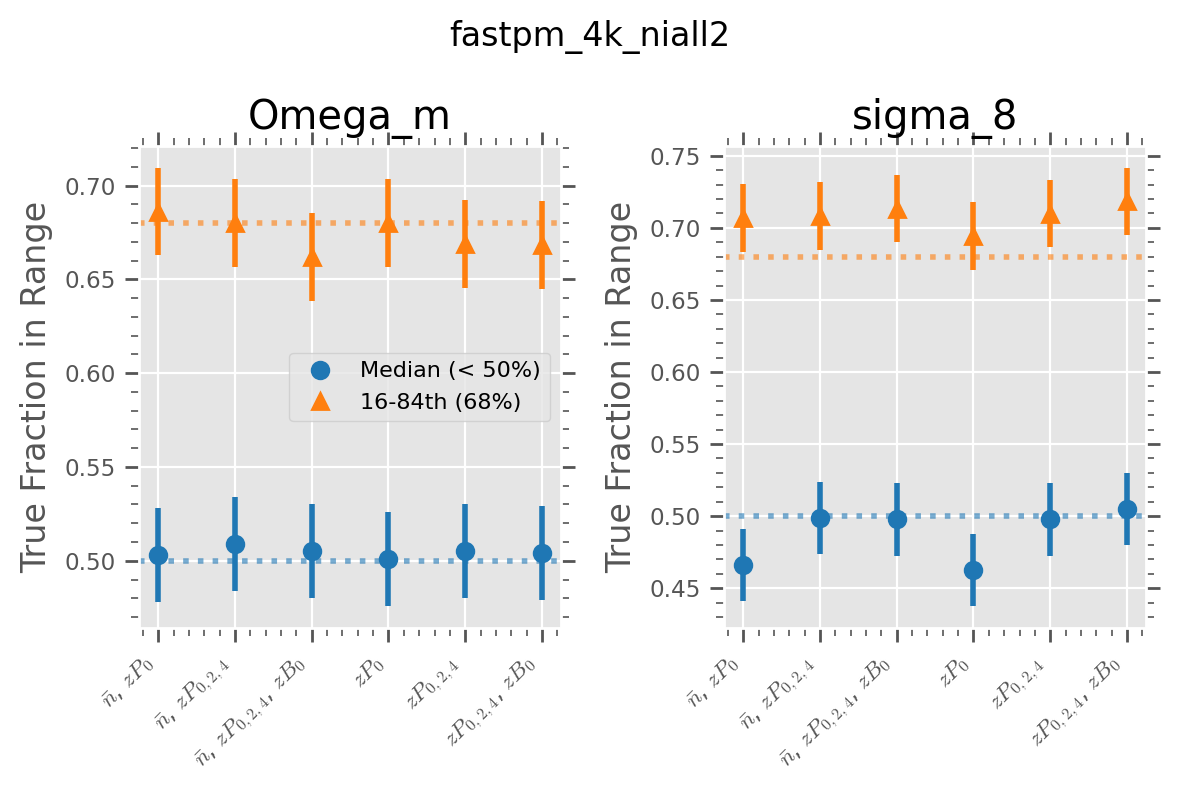

In [ ]:
import matplotlib.lines as mlines

def plot_aggregate_diagnostics(modeldir, axs, x_pos=0, **kwargs):
    samples = np.load(join(modeldir, 'posterior_samples.npy'))
    theta = np.load(join(modeldir, 'theta_test.npy'))

    # Measure 16th, 50th, and 84th percentiles of predictions
    p16, p50, p84 = np.percentile(samples, [16, 50, 84], axis=0)
    
    N = len(theta) # Total number of objects in the test set
    
    # Calculate Binomial standard errors on the expected fractions 
    # err = sqrt(p * (1 - p) / N)
    Nhods = 5  # number of HODs per unique cosmology
    err_med = np.sqrt((0.50 * 0.50) * Nhods / N)
    err_68 = np.sqrt((0.68 * 0.32) * Nhods / N)

    # Define the universal colors for your metrics
    color_med = 'tab:blue'
    color_68 = 'tab:orange'

    # Pop the label if it's passed, since we color by metric, not model now
    kwargs.pop('label', None)
    
    # Subplots for Omega_m (index 0) and sigma_8 (index 4)
    for idx, (j, label) in enumerate(zip([0,4], ['Omega_m', 'sigma_8'])):
        ax = axs[idx]

        # Aggregate masks over the whole test set
        below_median = theta[:, j] < p50[:, j]
        within_16_84 = (theta[:, j] >= p16[:, j]) & (theta[:, j] <= p84[:, j])

        # Calculate global fractions directly
        y_med = np.sum(below_median) / N
        y_68 = np.sum(within_16_84) / N
        
        # Plot Median calibration slightly to the left (forced color)
        ax.errorbar(x_pos, y_med, yerr=err_med, 
                    marker='o', color=color_med, linestyle='none', **kwargs)
        
        # Plot 68% calibration slightly to the right (forced color)
        ax.errorbar(x_pos, y_68, yerr=err_68, 
                    marker='^', color=color_68, linestyle='none', **kwargs)

        ax.set_ylabel('True Fraction in Range')
        ax.set_title(label)
        
        # Add reference lines using the matching colors (only draw on the first loop iteration)
        if x_pos == 0: 
            ax.axhline(0.50, color=color_med, linestyle=':', alpha=0.6)
            ax.axhline(0.68, color=color_68, linestyle=':', alpha=0.6)

f, axs = plt.subplots(1, 2, figsize=(6, 4))

# Use the enumeration index 'i' to space the models evenly along the x-axis
for i, m in enumerate(modeldirs):
    plot_aggregate_diagnostics(m, axs, x_pos=i)

# Create secondary legend to explain the markers and colors
marker_legend = [mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='none', label='Median (< 50%)'),
                 mlines.Line2D([], [], color='tab:orange', marker='^', linestyle='none', label='16-84th (68%)')]
axs[0].legend(handles=marker_legend, loc='best', fontsize=8)

# Format the x-axes to show model labels instead of numbers
for ax in axs:
    ax.set_xticks(range(len(modeldirs)))
    ax.set_xticklabels(simple(names), rotation=45, ha='right')

f.suptitle(sim)
plt.tight_layout()

fastpm_recnoise
fastpm_recnoise_tempcosmoonly
fastpm_recnoise_tempOms8
fastpm_recnoise_temploglinear


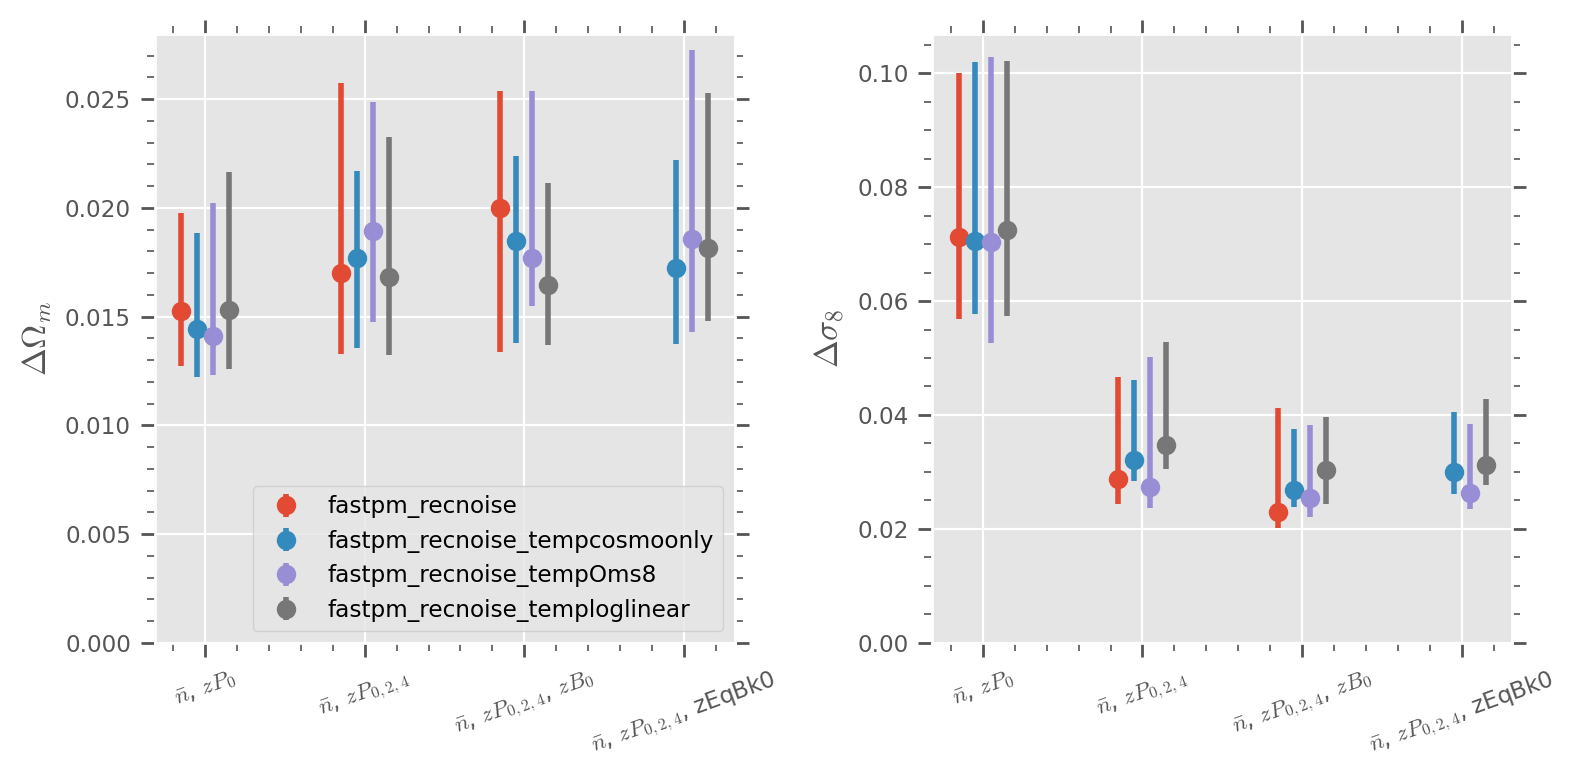

In [ ]:

def plot_model_stdev(modeldir, x_idx, axs, paramidx, label='', **kwargs):
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        return False

    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))
    xlen = np.load(join(modeldir, 'x_test.npy')).shape[-1]
    # if label is not None:
    #     label += f'(len:{xlen})'
    
    # Check if x_test exists, otherwise assume nbar logic is handled elsewhere or adapt as needed
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1] 

    mask = np.all(np.isclose(theta[:, paramidx], thetafid[paramidx], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    
    if np.sum(mask) == 0:
        return False

    # Keep only samples close to fiducial
    filtered_samples = samples[:, mask]
    # print(f'Found {np.sum(mask)} samples close to fiducial for {s}')
    stdev = np.std(filtered_samples, axis=0)

    for j, i in enumerate(paramidx):
        ax = axs[j]
        
        # Calculate percentiles across the surviving test points for this model
        param_stdevs = stdev[:, i]
        perc = np.percentile(param_stdevs, [50, 16, 84])
        
        ax.errorbar(
            x_idx, perc[0],
            yerr=[[perc[0] - perc[1]], [perc[2] - perc[0]]],
            fmt='o', label=label, **kwargs
        )
        ax.set_ylabel(f'$\Delta {param_names[i]}$')
        
    return True

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
param_names = [r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8']


f, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
axs = axs.flatten()

nbody='abacuslike'
# sims = [
#     f'fastpm_4k_niall{i}' for i in [2,5,6,7,8]
# ]
sims = [
    'fastpm_recnoise',
    'fastpm_recnoise_tempcosmoonly',
    'fastpm_recnoise_tempOms8',
    'fastpm_recnoise_temploglinear',
]
paramidxs = [
    [0,4],
    [0,4],
    [0,-1],
    [0,4],
]

for j, sim in enumerate(sims):
    print(sim)
    parentdir = f'{wdir}/{nbody}/{sim}/models/galaxy'
    labels = sorted(os.listdir(parentdir))
    valid_labels = []
    x_idx = 0

    for i, s in enumerate(labels):
        modeldir = join(parentdir, s, postfix)
        
        # Plot the point at the current x_idx. If data exists, advance the index and save the label.
        l = sim if i==0 else None
        if plot_model_stdev(modeldir, x_idx+(j-(len(sims)-1)/2)*0.1, axs, paramidxs[j], label=l, color=f'C{j}'):
            valid_labels.append(s)
            x_idx += 1

# Apply the categorical x-axis formatting from Cell 1
for ax in axs:
    ax.set_xticks(range(len(valid_labels)))
    ax.set_xticklabels(simple(valid_labels), rotation=20)
    ax.set_ylim(0, None)
axs[0].legend(loc='lower right', ncols=1)

plt.tight_layout()

fastpm_4k_niall2
fastpm_4k_niall5
fastpm_4k_niall6
fastpm_4k_niall7
fastpm_4k_niall8


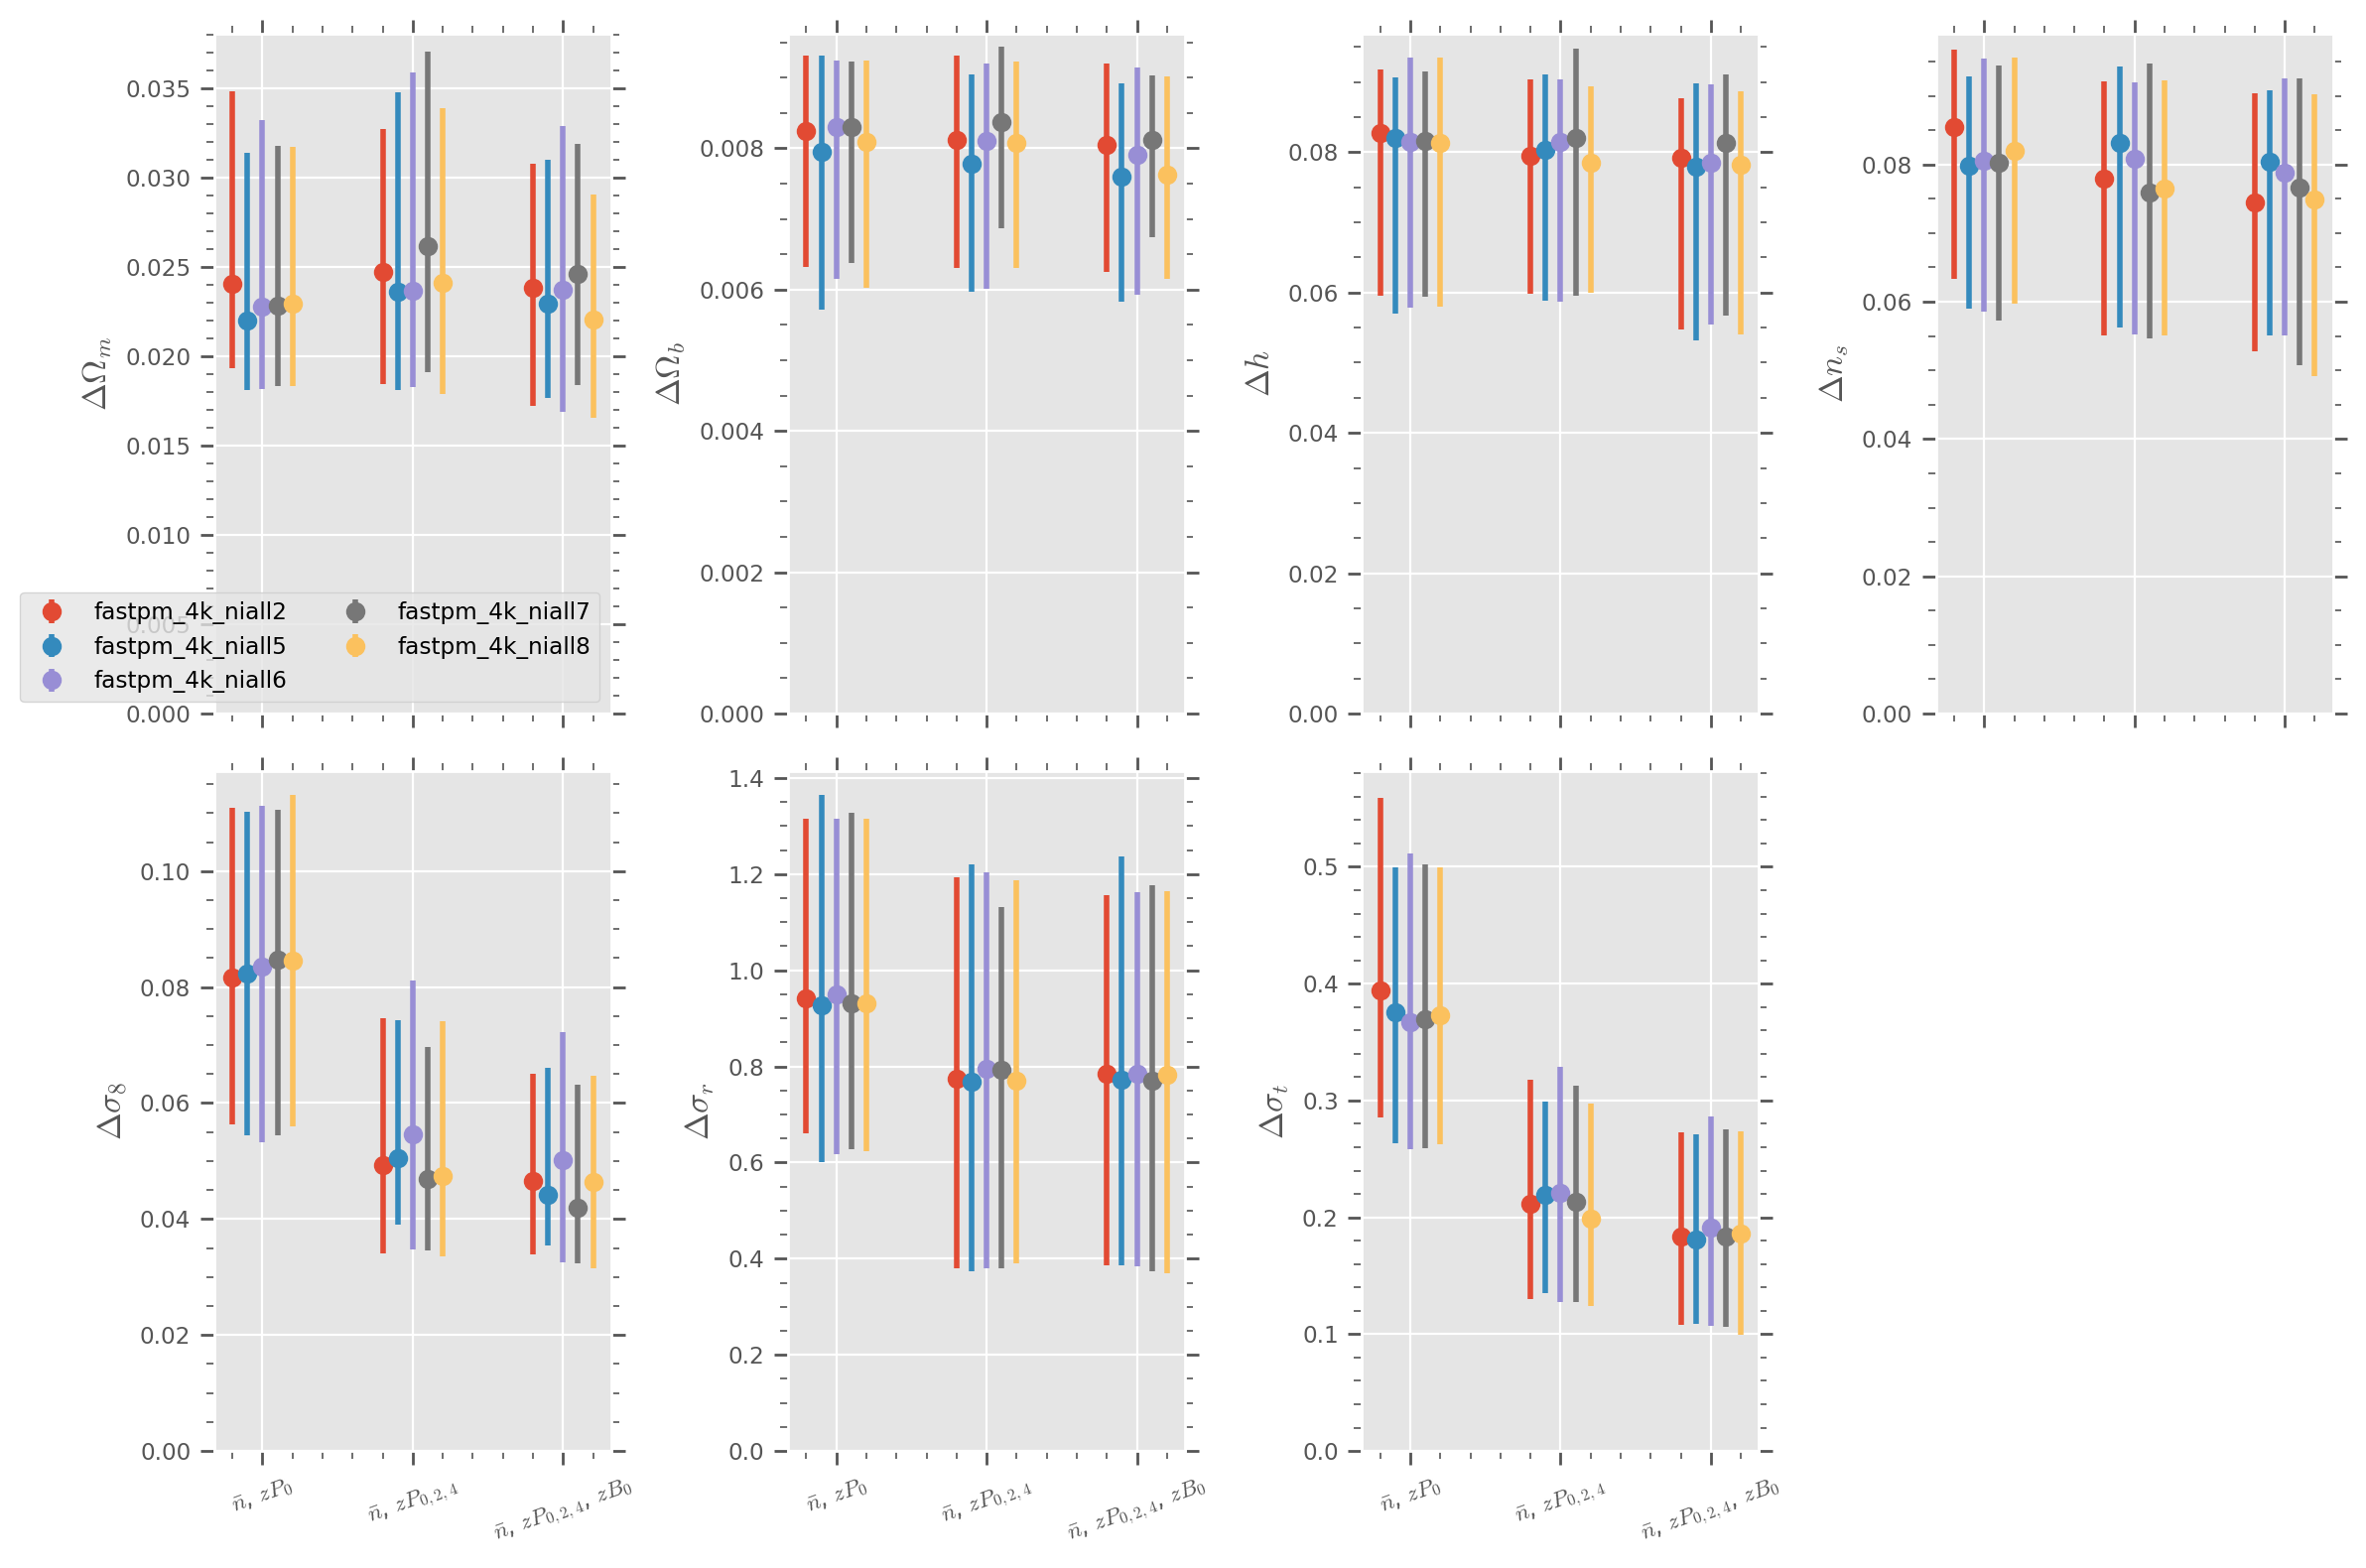

In [ ]:

def plot_model_stdev(modeldir, x_idx, axs, **kwargs):
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        return False

    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))
    
    # Check if x_test exists, otherwise assume nbar logic is handled elsewhere or adapt as needed
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1] 

    mask = np.all(np.isclose(theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    
    if np.sum(mask) == 0:
        return False

    # Keep only samples close to fiducial
    filtered_samples = samples[:, mask]
    # print(f'Found {np.sum(mask)} samples close to fiducial for {s}')
    stdev = np.std(filtered_samples, axis=0)

    for j, i in enumerate(range(7)):
        ax = axs[j]
        
        # Calculate percentiles across the surviving test points for this model
        param_stdevs = stdev[:, i]
        perc = np.percentile(param_stdevs, [50, 16, 84])
        
        ax.errorbar(
            x_idx, perc[0],
            yerr=[[perc[0] - perc[1]], [perc[2] - perc[0]]],
            fmt='o', **kwargs
        )
        ax.set_ylabel(f'$\Delta {param_names[i]}$')
        
    return True

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
param_names = [r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8', r'\sigma_r', r'\sigma_t']


f, axs = plt.subplots(2, 4, figsize=(12, 8), sharex=True)
axs = axs.flatten()

sims = [
    f'fastpm_4k_niall{i}' for i in [2,5,6,7,8]
]

for j, sim in enumerate(sims):
    print(sim)
    parentdir = f'{wdir}/quijotelike/{sim}/models/galaxy'
    labels = sorted(os.listdir(parentdir))
    valid_labels = []
    x_idx = 0

    for i, s in enumerate(labels):
        modeldir = join(parentdir, s, postfix)
        
        # Plot the point at the current x_idx. If data exists, advance the index and save the label.
        l = sim if i==0 else None
        if plot_model_stdev(modeldir, x_idx+(j-(len(sims)-1)/2)*0.1, axs, label=l, color=f'C{j}'):
            valid_labels.append(s)
            x_idx += 1

# Apply the categorical x-axis formatting from Cell 1
for ax in axs:
    ax.set_xticks(range(len(valid_labels)))
    ax.set_xticklabels(simple(valid_labels), rotation=20)
    ax.set_ylim(0, None)
axs[0].legend(loc='lower right', ncols=2)
axs[-1].axis('off')

plt.tight_layout()

In [ ]:
filepath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody/L1000-N128/99/diag/galaxies/hod00001.h5'
a = '0.666667'

with h5py.File(filepath, 'r') as f:
    print(f[a].keys())
    k3D = f[a]['Pk_k3D'][...]
    Pk = f[a]['Pk'][...]
    k123 = f[a]['Bk_k123'][...]

Pk = Pk[k3D<0.4]
k3D = k3D[k3D < 0.4]

<KeysViewHDF5 ['Bk', 'Bk_k123', 'Pk', 'Pk_k3D', 'Qk', 'bPk', 'bPk_k3D', 'zBk', 'zBk_k123', 'zPk', 'zPk_k3D', 'zQk', 'zbPk', 'zbPk_k3D']>


In [ ]:
import numpy as np

import numpy as np

def log2_avg(A, s=0):
    A = np.asarray(A)
    if len(A) <= s: return A 
    idx = s + (1 << np.arange((len(A) - s).bit_length())) - 1
    idx = np.r_[np.arange(s), idx] if s > 0 else idx
    return np.add.reduceat(A, idx) / np.diff(np.append(idx, len(A)))

s = 30
res = log2_avg(Pk[:,0], s=s)
resk = log2_avg(k3D, s=s)

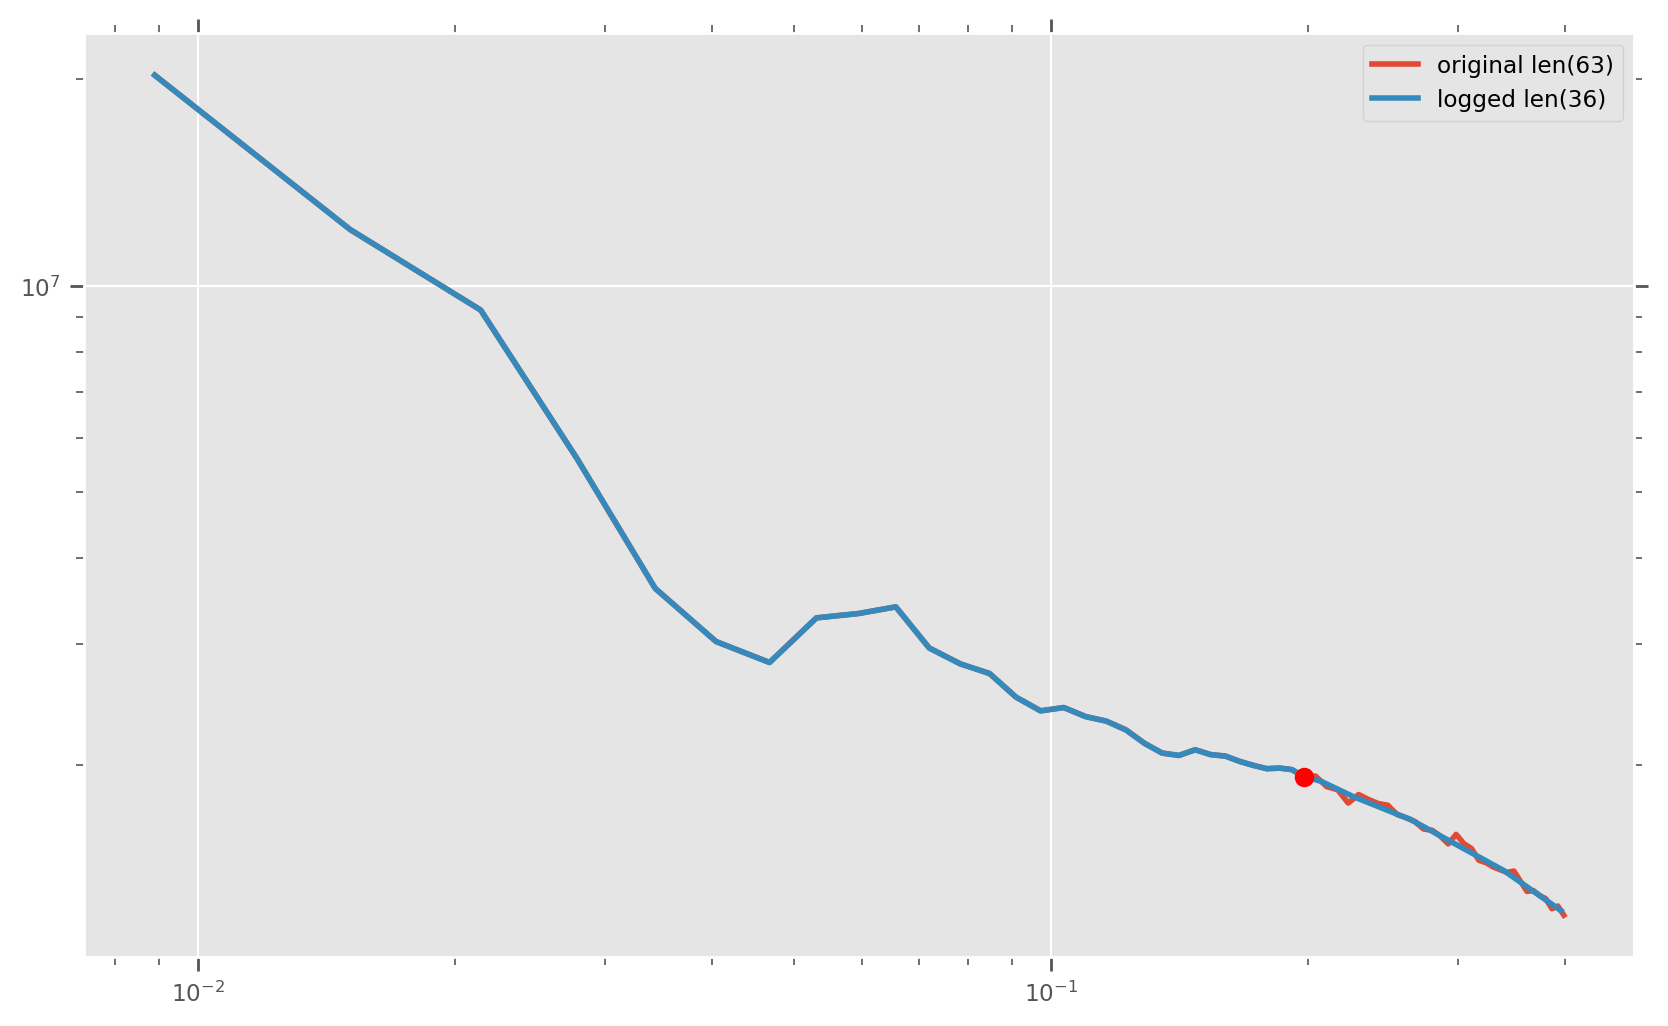

In [ ]:
plt.loglog()
plt.plot(k3D, Pk[:,0], label=f'original len({len(k3D)})')
plt.plot(resk, res, label=f'logged len({len(resk)})')
plt.plot(resk[s], res[s], 'ro')
plt.legend()

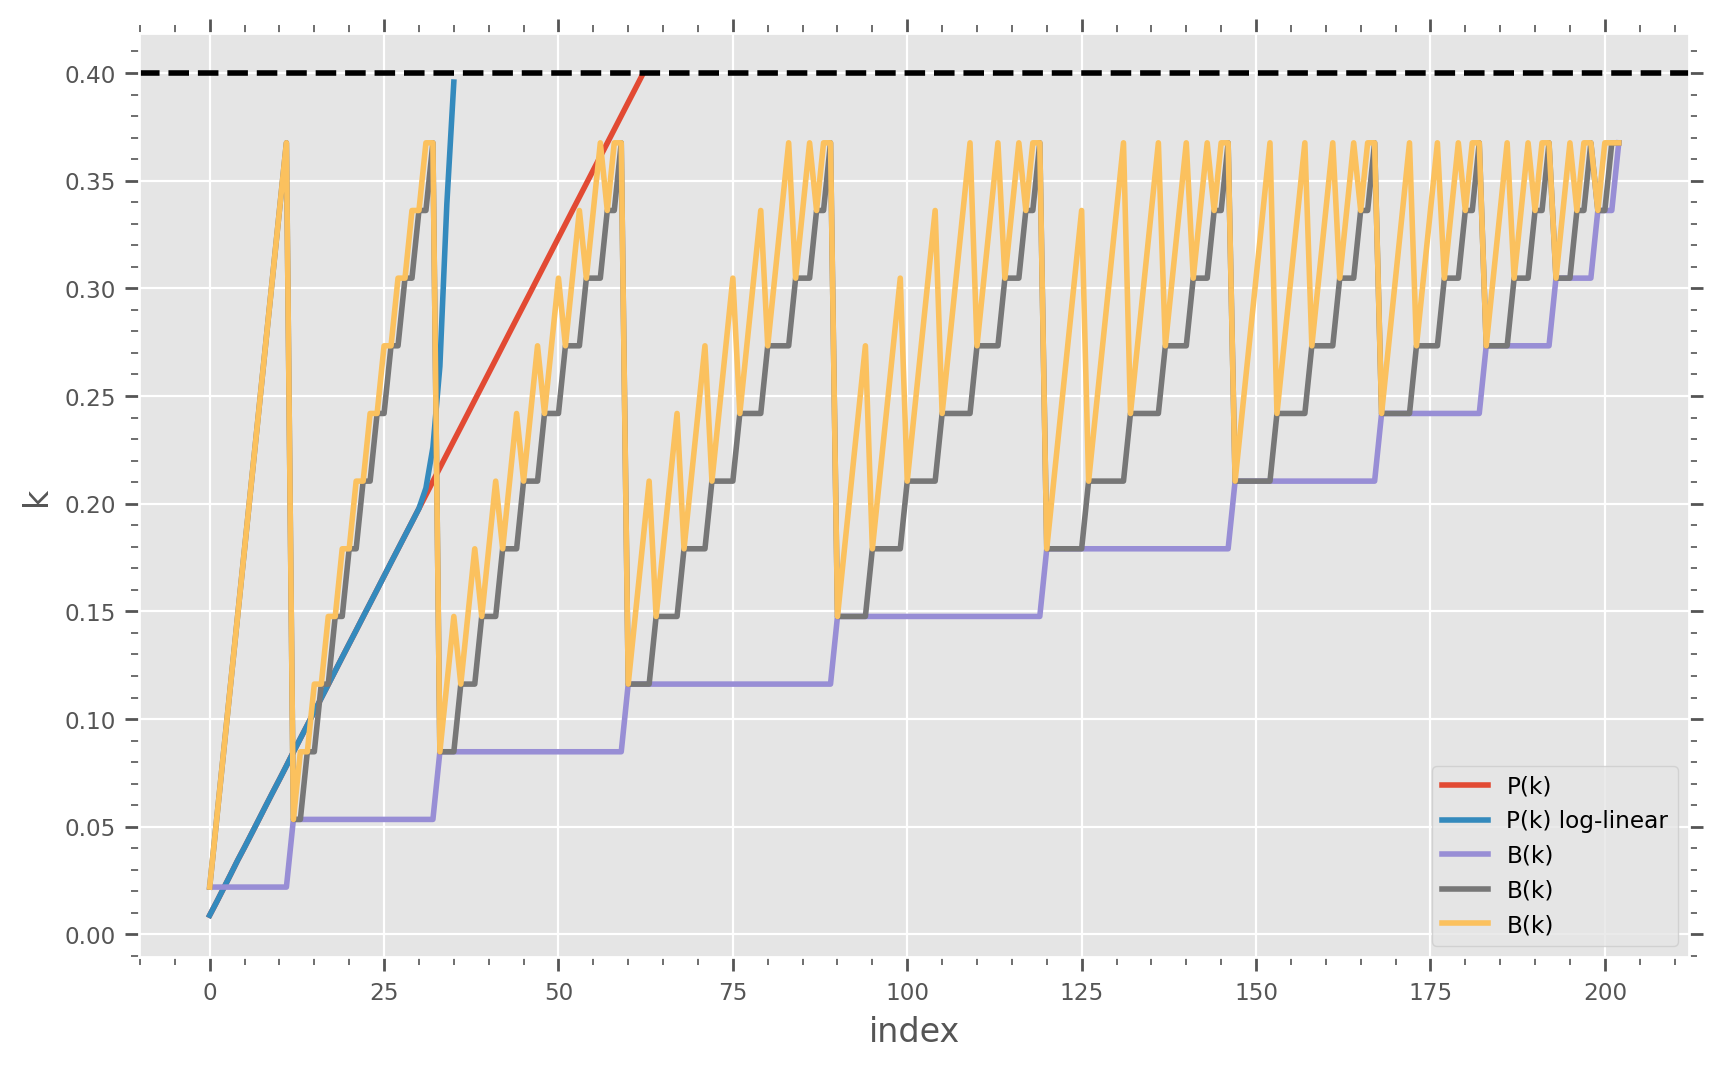

In [ ]:
f, ax = plt.subplots()

ax.plot(k3D, label='P(k)')
ax.plot(resk, label='P(k) log-linear')
ax.plot(k123.T, label='B(k)')
ax.axhline(0.4, linestyle='--', color='k')
ax.set(xlabel='index', ylabel='k')
ax.legend()

In [ ]:

def plot_model_stdev(modeldir, x_idx, axs, paramidx, label='', **kwargs):
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        return False

    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))
    xlen = np.load(join(modeldir, 'x_test.npy')).shape[-1]
    # if label is not None:
    #     label += f'(len:{xlen})'
    
    # Check if x_test exists, otherwise assume nbar logic is handled elsewhere or adapt as needed
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1] 

    mask = np.all(np.isclose(theta[:, paramidx], thetafid[paramidx], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    
    if np.sum(mask) == 0:
        return False

    # Keep only samples close to fiducial
    filtered_samples = samples[:, mask]
    # print(f'Found {np.sum(mask)} samples close to fiducial for {s}')
    stdev = np.std(filtered_samples, axis=0)

    for j, i in enumerate(paramidx):
        ax = axs[j]
        
        # Calculate percentiles across the surviving test points for this model
        param_stdevs = stdev[:, i]
        perc = np.percentile(param_stdevs, [50, 16, 84])
        
        ax.errorbar(
            x_idx, perc[0],
            yerr=[[perc[0] - perc[1]], [perc[2] - perc[0]]],
            fmt='o', label=label, **kwargs
        )
        ax.set_ylabel(f'$\Delta {param_names[i]}$')
        
    return True

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
param_names = [r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8']


f, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
axs = axs.flatten()

nbodys=[
    'quijotelike',
    'abacuslike'
]
# sims = [
#     f'fastpm_4k_niall{i}' for i in [2,5,6,7,8]
# ]
sims = [
    'fastpm_4k_niall2',
    'fastpm_recnoise_tempcosmoonly',
]
paramidxs = [
    [0,4],
    [0,4],
    [0,-1],
    [0,4],
]

for j, sim in enumerate(sims):
    print(sim)
    nbody = nbodys[j]
    parentdir = f'{wdir}/{nbody}/{sim}/models/galaxy'
    labels = sorted(os.listdir(parentdir))
    valid_labels = []
    x_idx = 0

    for i, s in enumerate(labels):
        modeldir = join(parentdir, s, postfix)
        
        # Plot the point at the current x_idx. If data exists, advance the index and save the label.
        l = sim if i==0 else None
        if plot_model_stdev(modeldir, x_idx+(j-(len(sims)-1)/2)*0.1, axs, paramidxs[j], label=l, color=f'C{j}'):
            valid_labels.append(s)
            x_idx += 1

# Apply the categorical x-axis formatting from Cell 1
for ax in axs:
    ax.set_xticks(range(len(valid_labels)))
    ax.set_xticklabels(simple(valid_labels), rotation=20)
    ax.set_ylim(0, None)
axs[0].legend(loc='lower right', ncols=1)

plt.tight_layout()

In [18]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_hodz/L1000-N128'

a = '0.666667'
hods = []
for i in range(1000):
    diagpath = join(basepath, str(i), 'diag', 'galaxies')
    filepath = join(diagpath, 'hod00001.h5')
    try:
        with h5py.File(filepath, 'r') as f:
            hods.append(f.attrs['HOD_params'])
            hodnames = f.attrs['HOD_names']
    except Exception as e:
        continue
hods = np.array(hods)

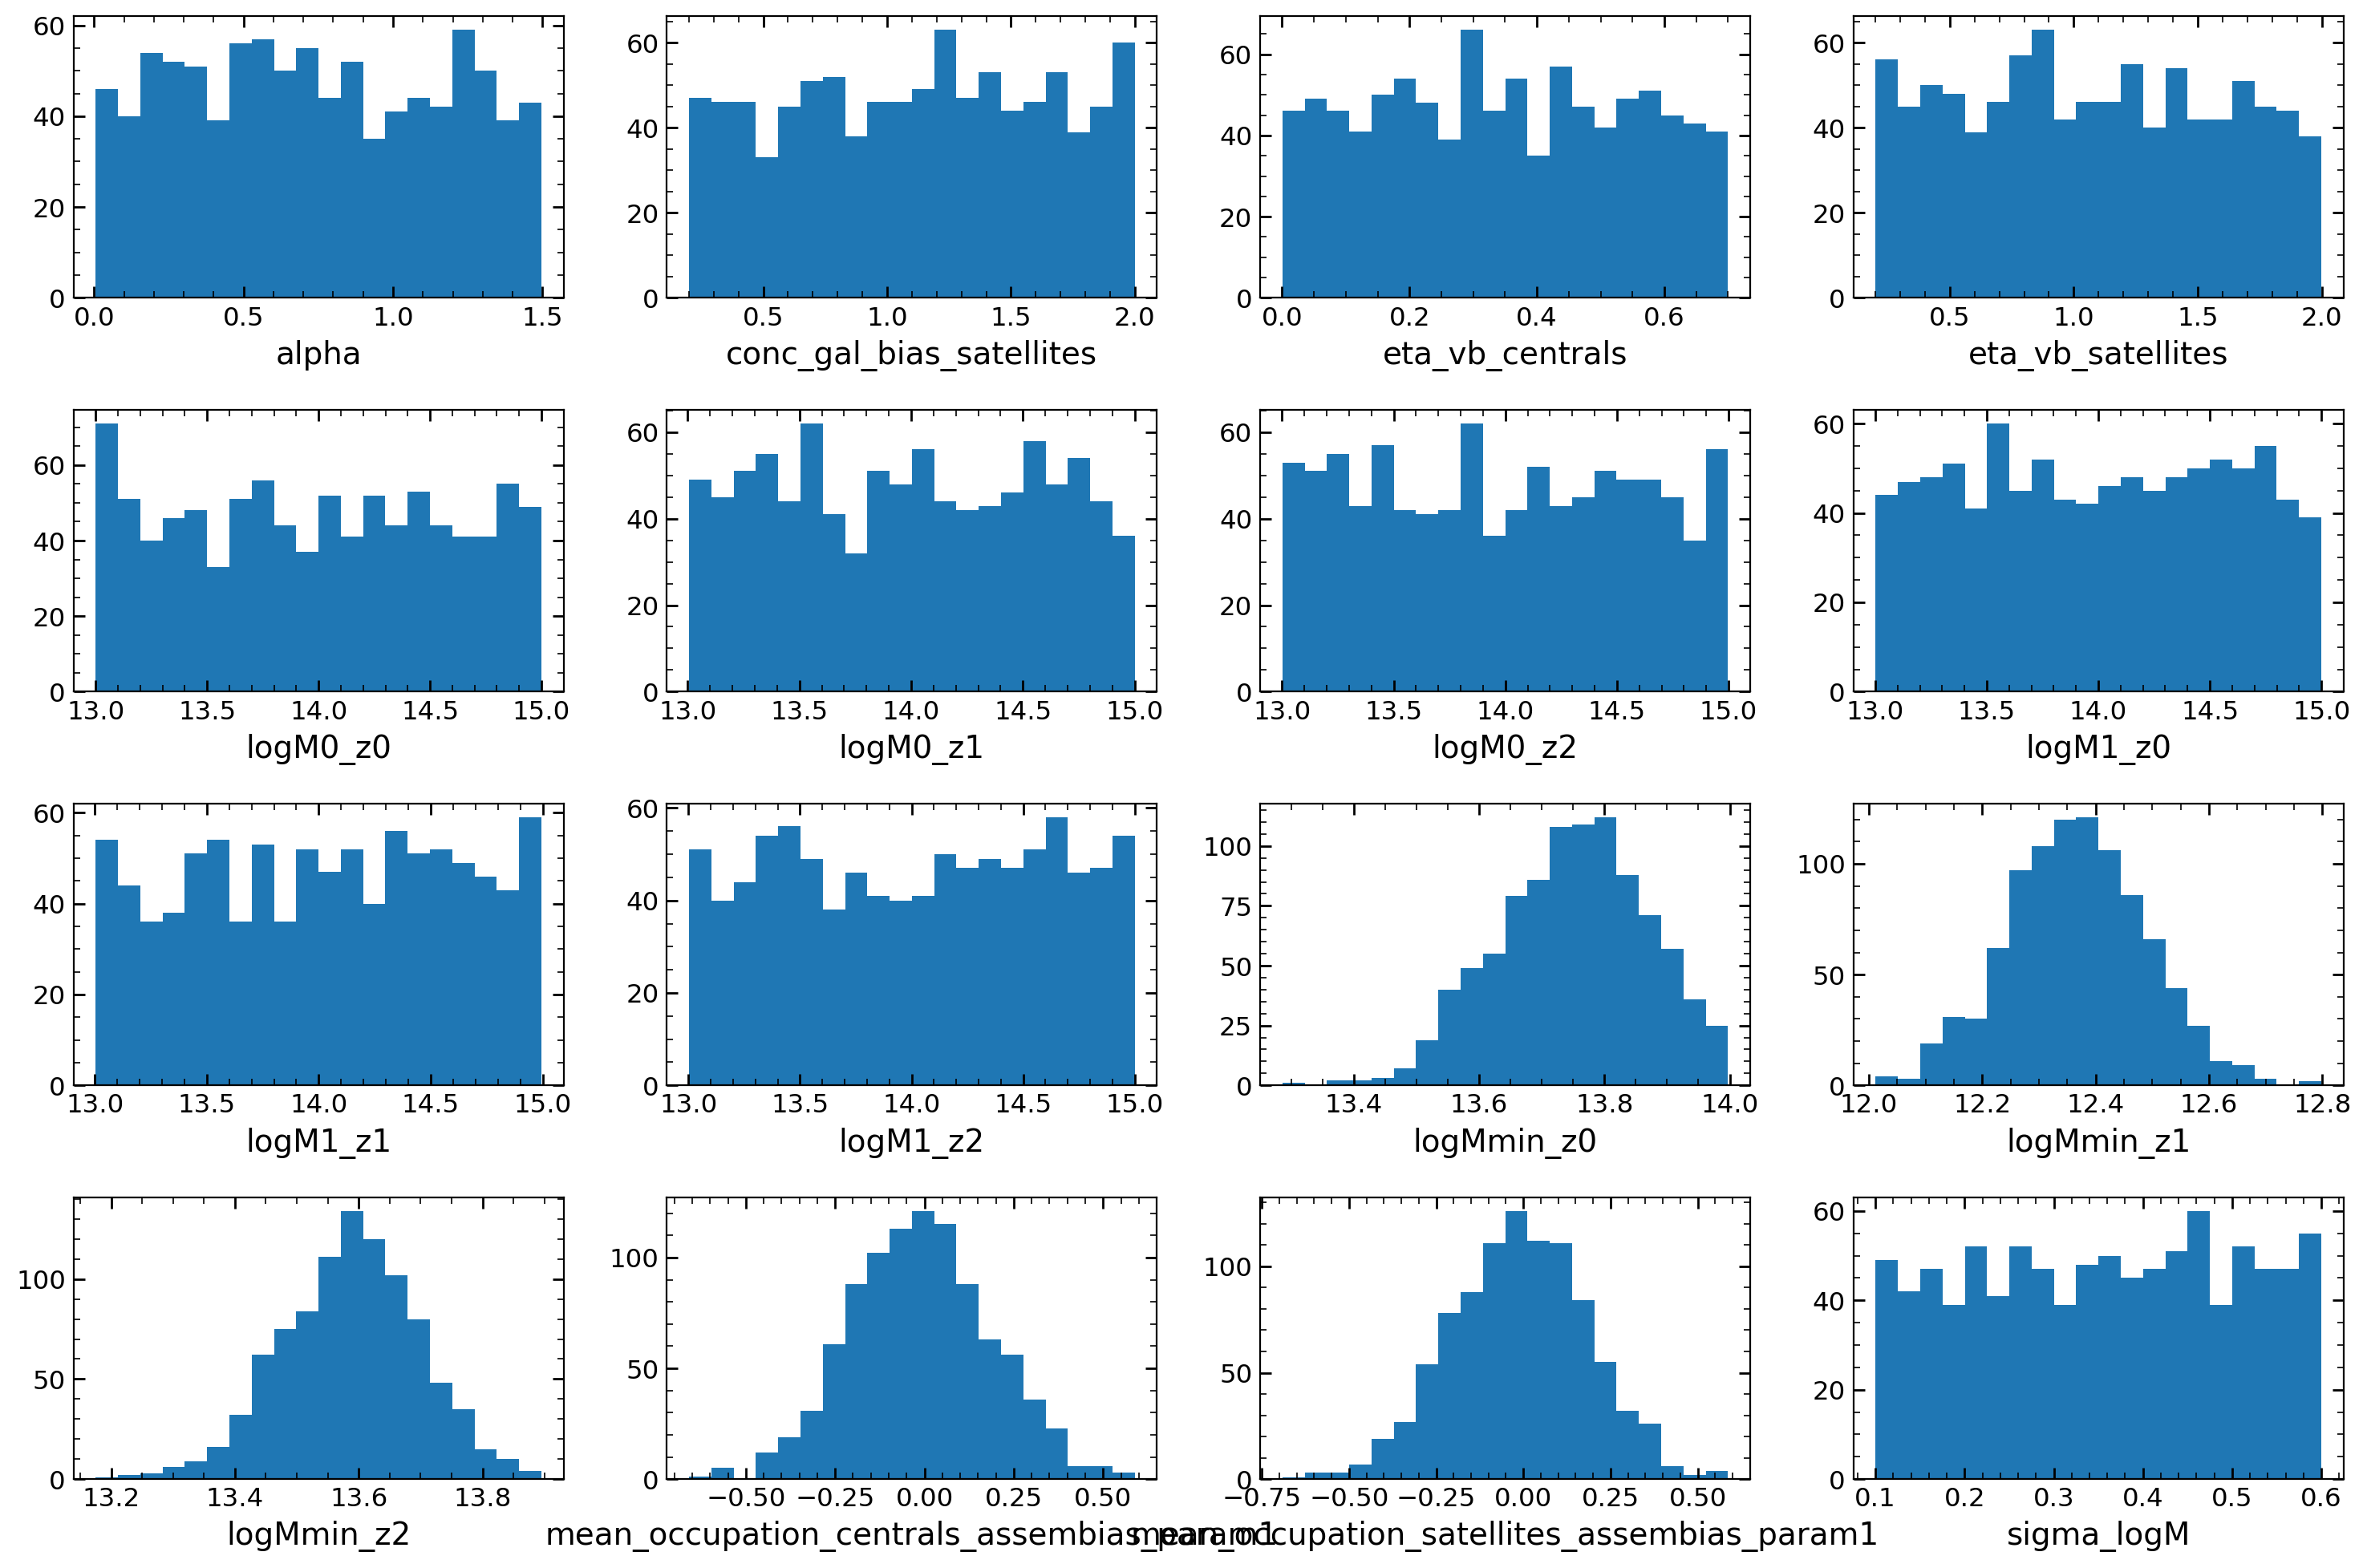

In [23]:
f, axs = plt.subplots(4,4, figsize=(15,10))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.hist(hods[:,i], 20)
    ax.set_xlabel(hodnames[i])
plt.tight_layout()